# k-Maximum Inner Product Attention for Graph Transformers with Hybrid k-Allocation

**Research Question:** Can stronger k-allocation strategies for k-MIP attention , including paper-aligned global annealing, per-layer schedules, and querywise entropy-adaptive k, improve the speed/accuracy trade-off on LRGB while staying faithful to the k-MIP paper?

This notebook reproduces the GPS+k-MIP setup on **three practical LRGB datasets**
1. **Peptides-func**
2. **Peptides-struct**
3. **PascalVOC-SP**

and extends it with four k-allocation strategies
1. **Fixed k** — baseline
2. **Cosine / Linear / Step epoch schedules** — the paper-motivated annealing family.
3. **Layerwise k allocation** — larger k in early layers, smaller k in deep layers.
4. **Hybrid layerwise + querywise entropy-adaptive k** — uncertain queries receive larger k inside each layer.


The notebook also includes an **optional KeOps backend** for symbolic top-k search. If `pykeops` compiles successfully in Colab, the attention layer can use a KeOps-style top-k routine to avoid materializing the dense `N x N` score matrix. If KeOps is unavailable, the notebook falls back to the dense implementation automatically. Adapt this method accordingly.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
RESULTS_DIR = '/content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults'
DATA_DIR    = '/content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/Data'
SPLIT_DIR = os.path.join(RESULTS_DIR, 'splits')

for p in [RESULTS_DIR, DATA_DIR, SPLIT_DIR]:
    os.makedirs(p, exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR}")
print(f"Data cached at: {DATA_DIR}")
print(f"Paper-style split metadata saved to: {SPLIT_DIR}")


Results will be saved to: /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults
Data cached at: /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/Data
Paper-style split metadata saved to: /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/splits


## 1. Setup and Imports

In [ ]:
%%capture
%pip install -q torch-geometric==2.5.3 pykeops==2.2.3 ogb scikit-learn pandas matplotlib


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import json
import math
import time
from copy import deepcopy
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric
from torch.utils.data import Subset
from sklearn.metrics import average_precision_score, f1_score
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data
from torch_geometric.datasets import LRGBDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_batch
from torch_geometric.nn import global_mean_pool, global_add_pool

torch.serialization.add_safe_globals([Data])

# Device configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"BF16 supported: {torch.cuda.is_bf16_supported()}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Metal Performance Shaders)")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Optional KeOps support
KEOPS_AVAILABLE = False
KEOPS_IMPORT_ERROR = None
generic_argkmin = None
try:
    from pykeops.torch import generic_argkmin
    KEOPS_AVAILABLE = True
except Exception as e:
    KEOPS_IMPORT_ERROR = repr(e)

DEFAULT_ATTENTION_BACKEND = 'keops' if KEOPS_AVAILABLE else 'dense'
print(f"KeOps available: {KEOPS_AVAILABLE}")
if not KEOPS_AVAILABLE:
    print(f"KeOps import failed -> fallback to dense attention. Reason: {KEOPS_IMPORT_ERROR}")
else:
    print("Default attention backend: keops")


Using CUDA: NVIDIA A100-SXM4-40GB
GPU Memory: 42.4 GB
BF16 supported: True
PyTorch version: 2.10.0+cu128
PyG version: 2.5.3
[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK
KeOps available: True
Default attention backend: keops


## 2. k-MIP Attention Implementation

The implementation below supports
- **standard k-MIP**
- **querywise entropy-adaptive k**
- **hybrid layerwise + entropy-adaptive plans**
- **dense backend**
- **optional KeOps backend** ( this notebook uses dense backend but includes keOps as an option, so edit the code for the full keOps optionality).

For the KeOps backend, the top-k search is performed without explicitly constructing the full score matrix. For querywise entropy adaptation under KeOps, entropy is estimated from the **top-k_max probe set** rather than the full score matrix, which keeps the implementation memory-friendly.



In [ ]:
import os

_KEOPS_TOPK_ROUTINE_CACHE = {}

def get_keops_argtopk_routine(head_dim, k):
    if not KEOPS_AVAILABLE:
        raise RuntimeError("KeOps is not available in this session.")
    key = (int(head_dim), int(k))
    if key not in _KEOPS_TOPK_ROUTINE_CACHE:
        _KEOPS_TOPK_ROUTINE_CACHE[key] = generic_argkmin(
            "Minus(Sum(x * y))",
            f"a = Vi({int(k)})",
            f"x = Vi({int(head_dim)})",
            f"y = Vj({int(head_dim)})",
        )
    return _KEOPS_TOPK_ROUTINE_CACHE[key]


class KMIPAttention(nn.Module):
    """
    Unified k-MIP attention layer with
      - dense or optional KeOps backend
      - fixed-k attention
      - querywise entropy-adaptive k
      - hybrid layerwise + entropy-adaptive plans

    `current_k` may be
      - int: fixed k for this layer
      - dict: {
            'adaptive': bool,
            'k_min': int,
            'k_max': int,
            'entropy_alpha': float
        }
      - None: default fixed self.k
    """

    def __init__(self, hidden_dim, num_heads, k, dropout=0.0, backend='auto'):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.k = int(k)
        self.backend = backend
        self.head_dim = hidden_dim // num_heads
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"

        self.query_projection = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.key_projection = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.value_projection = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.output_projection = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.attention_dropout = nn.Dropout(dropout)
        self.scale_factor = math.sqrt(self.head_dim)
        self.last_debug = {}

    def _resolve_backend(self):
        if self.backend == 'auto':
            return 'keops' if KEOPS_AVAILABLE else 'dense'
        if self.backend == 'keops' and not KEOPS_AVAILABLE:
            return 'dense'
        return self.backend

    def _normalize_plan(self, current_k, max_nodes):
        if current_k is None:
            return {'adaptive': False, 'k_min': min(self.k, max_nodes), 'k_max': min(self.k, max_nodes), 'entropy_alpha': 1.0}
        if isinstance(current_k, int):
            kk = max(1, min(int(current_k), max_nodes))
            return {'adaptive': False, 'k_min': kk, 'k_max': kk, 'entropy_alpha': 1.0}
        if isinstance(current_k, dict):
            k_max = max(1, min(int(current_k.get('k_max', self.k)), max_nodes))
            k_min = max(1, min(int(current_k.get('k_min', k_max)), k_max))
            return {
                'adaptive': bool(current_k.get('adaptive', False)),
                'k_min': k_min,
                'k_max': k_max,
                'entropy_alpha': float(current_k.get('entropy_alpha', 1.0)),
            }
        raise TypeError(f"Unsupported current_k type: {type(current_k)}")

    def _make_fixed_query_k(self, batch_size, max_nodes, k_max, batch_mask, device):
        query_k = torch.full((batch_size, self.num_heads, max_nodes), fill_value=k_max, dtype=torch.long, device=device)
        if batch_mask is not None:
            # Expand batch_mask to cover all heads
            query_k = query_k * batch_mask.unsqueeze(1).long()
        return query_k

    def _compute_querywise_k_dense(self, attention_scores, batch_mask, k_min, k_max, entropy_alpha):
        probs = F.softmax(attention_scores, dim=-1).nan_to_num(0.0)
        entropy = -(probs * torch.log(probs.clamp_min(1e-12))).sum(dim=-1)  # [B, H, N]

        if batch_mask is not None:
            valid_counts = batch_mask.sum(dim=-1).clamp(min=2).float()       # [B]
            max_entropy = torch.log(valid_counts).view(-1, 1, 1)             # [B, 1, 1]
            query_mask = batch_mask.unsqueeze(1).expand(-1, self.num_heads, -1) # [B, H, N]
        else:
            max_entropy = torch.full(
                (attention_scores.size(0), 1, 1),
                float(math.log(max(attention_scores.size(-1), 2))),
                device=attention_scores.device,
                dtype=attention_scores.dtype,
            )
            query_mask = None

        entropy_norm = (entropy / max_entropy.clamp_min(1e-8)).clamp(0.0, 1.0)
        entropy_norm = entropy_norm.pow(entropy_alpha)

        query_k = k_min + torch.round((k_max - k_min) * entropy_norm).long()
        query_k = query_k.clamp(min=k_min, max=k_max)

        if query_mask is not None:
            query_k = query_k * query_mask.long()
        return query_k, entropy_norm

    def _compute_querywise_k_from_selected_scores(self, selected_scores, n_valid, k_min, k_max, entropy_alpha):
        # selected_scores: [N, k_max], already sorted desc
        probs = F.softmax(selected_scores, dim=-1).nan_to_num(0.0)
        entropy = -(probs * torch.log(probs.clamp_min(1e-12))).sum(dim=-1)  # [N]
        denom = math.log(max(min(n_valid, k_max), 2))
        entropy_norm = (entropy / max(denom, 1e-8)).clamp(0.0, 1.0)
        entropy_norm = entropy_norm.pow(entropy_alpha)

        query_k = k_min + torch.round((k_max - k_min) * entropy_norm).long()
        query_k = query_k.clamp(min=k_min, max=k_max)
        return query_k, entropy_norm

    def _forward_dense(self, node_features, batch_mask, plan):
        batch_size, max_nodes, _ = node_features.shape
        k_max = plan['k_max']

        queries = self.query_projection(node_features).view(batch_size, max_nodes, self.num_heads, self.head_dim).transpose(1, 2)
        keys = self.key_projection(node_features).view(batch_size, max_nodes, self.num_heads, self.head_dim).transpose(1, 2)
        values = self.value_projection(node_features).view(batch_size, max_nodes, self.num_heads, self.head_dim).transpose(1, 2)

        attention_scores = torch.matmul(queries, keys.transpose(-2, -1)) / self.scale_factor
        if batch_mask is not None:
            key_mask = batch_mask.unsqueeze(1).unsqueeze(2)
            attention_scores = attention_scores.masked_fill(~key_mask, float('-inf'))

        if plan['adaptive']:
            query_k, entropy_norm = self._compute_querywise_k_dense(
                attention_scores, batch_mask=batch_mask,
                k_min=plan['k_min'], k_max=k_max, entropy_alpha=plan['entropy_alpha']
            )
        else:
            query_k = self._make_fixed_query_k(batch_size, max_nodes, k_max, batch_mask, node_features.device)
            entropy_norm = None

        topk_values, topk_indices = torch.topk(attention_scores, k=k_max, dim=-1, largest=True, sorted=True)
        ranks = torch.arange(k_max, device=node_features.device).view(1, 1, 1, -1)
        keep_mask = ranks < query_k.unsqueeze(-1)
        masked_topk_values = topk_values.masked_fill(~keep_mask, float('-inf'))

        topk_attention_weights = F.softmax(masked_topk_values, dim=-1).nan_to_num(0.0)
        topk_attention_weights = self.attention_dropout(topk_attention_weights)

        gather_index = topk_indices.unsqueeze(-1).expand(-1, -1, -1, -1, self.head_dim)
        expanded_values = values.unsqueeze(2).expand(-1, -1, max_nodes, -1, -1)
        gathered_values = torch.gather(expanded_values, 3, gather_index)

        attended_values = (topk_attention_weights.unsqueeze(-1) * gathered_values).sum(dim=-2)
        if batch_mask is not None:
            attended_values = attended_values * batch_mask.unsqueeze(1).unsqueeze(-1)

        final_entropy = -(topk_attention_weights * torch.log(topk_attention_weights.clamp_min(1e-12))).sum(dim=-1)
        if batch_mask is not None:
            # Fix: Expand valid_query_mask to match the num_heads dimension of final_entropy and query_k
            valid_query_mask = batch_mask.unsqueeze(1).expand(-1, self.num_heads, -1)
            mean_entropy = final_entropy[valid_query_mask].mean() if valid_query_mask.any() else torch.tensor(0.0, device=node_features.device)
            valid_qk = query_k[valid_query_mask]
        else:
            mean_entropy = final_entropy.mean()
            valid_qk = query_k.view(-1)

        attended_values = attended_values.transpose(1, 2).contiguous().view(batch_size, max_nodes, self.hidden_dim)
        output_features = self.output_projection(attended_values)

        self.last_debug = {
            'backend': 'dense',
            'effective_k': float(valid_qk.float().mean().item()) if valid_qk.numel() > 0 else 0.0,
            'query_k_mean': float(valid_qk.float().mean().item()) if valid_qk.numel() > 0 else 0.0,
            'query_k_min': int(valid_qk.min().item()) if valid_qk.numel() > 0 else 0,
            'query_k_max': int(valid_qk.max().item()) if valid_qk.numel() > 0 else 0,
            'attention_entropy': mean_entropy.detach(),
            'entropy_mean': float(entropy_norm.mean().item()) if entropy_norm is not None else None,
        }
        return output_features, self.last_debug

    def _keops_topk_indices(self, q, k, topk):
        routine = get_keops_argtopk_routine(q.shape[-1], topk)
        idx = routine(q.contiguous(), k.contiguous())
        if idx.dtype != torch.long:
            idx = idx.long()
        return idx.to(q.device)

    def _forward_keops(self, node_features, batch_mask, plan):
        batch_size, max_nodes, _ = node_features.shape
        k_max = plan['k_max']

        queries = self.query_projection(node_features).view(batch_size, max_nodes, self.num_heads, self.head_dim).transpose(1, 2)
        keys = self.key_projection(node_features).view(batch_size, max_nodes, self.num_heads, self.head_dim).transpose(1, 2)
        values = self.value_projection(node_features).view(batch_size, max_nodes, self.num_heads, self.head_dim).transpose(1, 2)

        output = torch.zeros(batch_size, self.num_heads, max_nodes, self.head_dim, device=node_features.device, dtype=node_features.dtype)
        entropies, query_k_means, query_k_mins, query_k_maxs = [], [], [], []

        for b in range(batch_size):
            n_valid = int(batch_mask[b].sum().item()) if batch_mask is not None else max_nodes
            if n_valid <= 0:
                continue

            for h in range(self.num_heads):
                q = queries[b, h, :n_valid, :]
                k = keys[b, h, :n_valid, :]
                v = values[b, h, :n_valid, :]

                topk_idx = self._keops_topk_indices(q, k, k_max)
                gathered_k = k[topk_idx]
                selected_scores = (q.unsqueeze(1) * gathered_k).sum(dim=-1) / self.scale_factor
                selected_scores, order = torch.sort(selected_scores, dim=-1, descending=True)
                topk_idx = torch.gather(topk_idx, 1, order)
                gathered_v = v[topk_idx]

                if plan['adaptive']:
                    query_k, entropy_norm = self._compute_querywise_k_from_selected_scores(
                        selected_scores=selected_scores,
                        n_valid=n_valid,
                        k_min=plan['k_min'],
                        k_max=k_max,
                        entropy_alpha=plan['entropy_alpha'],
                    )
                else:
                    query_k = torch.full((n_valid,), fill_value=k_max, dtype=torch.long, device=node_features.device)
                    entropy_norm = None

                rank_ids = torch.arange(k_max, device=node_features.device).unsqueeze(0)
                keep_mask = rank_ids < query_k.unsqueeze(-1)
                masked_scores = selected_scores.masked_fill(~keep_mask, float('-inf'))
                topk_attention_weights = F.softmax(masked_scores, dim=-1).nan_to_num(0.0)
                topk_attention_weights = self.attention_dropout(topk_attention_weights)
                attended = (topk_attention_weights.unsqueeze(-1) * gathered_v).sum(dim=1)
                output[b, h, :n_valid, :] = attended

                final_entropy = -(topk_attention_weights * torch.log(topk_attention_weights.clamp_min(1e-12))).sum(dim=-1)
                entropies.append(final_entropy.mean())
                query_k_means.append(query_k.float().mean())
                query_k_mins.append(query_k.min())
                query_k_maxs.append(query_k.max())

        output = output.transpose(1, 2).contiguous().view(batch_size, max_nodes, self.hidden_dim)
        output_features = self.output_projection(output)

        mean_entropy = torch.stack(entropies).mean() if entropies else torch.tensor(0.0, device=node_features.device)
        mean_query_k = torch.stack(query_k_means).mean().item() if query_k_means else 0.0
        min_query_k = int(torch.stack(query_k_mins).min().item()) if query_k_mins else 0
        max_query_k = int(torch.stack(query_k_maxs).max().item()) if query_k_maxs else 0

        self.last_debug = {
            'backend': 'keops',
            'effective_k': mean_query_k,
            'query_k_mean': mean_query_k,
            'query_k_min': min_query_k,
            'query_k_max': max_query_k,
            'attention_entropy': mean_entropy.detach(),
            'entropy_mean': None,
        }
        return output_features, self.last_debug

    def forward(self, node_features, batch_mask=None, current_k=None):
        plan = self._normalize_plan(current_k=current_k, max_nodes=node_features.size(1))
        backend = self._resolve_backend()

        if backend == 'keops':
            try:
                return self._forward_keops(node_features, batch_mask=batch_mask, plan=plan)
            except Exception as e:
                print(f"[warning] KeOps backend failed inside forward, switching to dense for this run. Reason: {repr(e)}")
                self.backend = 'dense'
                return self._forward_dense(node_features, batch_mask=batch_mask, plan=plan)

        return self._forward_dense(node_features, batch_mask=batch_mask, plan=plan)


In [ ]:
# Optional: quick backend check
print(f"Default attention backend for this notebook: {DEFAULT_ATTENTION_BACKEND}")
if KEOPS_AVAILABLE:
    print("KeOps is available, so symbolic top-k search can be used.")
else:
    print("KeOps is unavailable, so experiments will use the dense top-k implementation.")


Default attention backend for this notebook: keops
KeOps is available, so symbolic top-k search can be used.


## 4. GraphGPS Framework Implementation


In [ ]:
class GatedGCNLayer(nn.Module):
    """GatedGCN message-passing layer as used in GraphGPS."""

    def __init__(self, hidden_dim, edge_dim=None, dropout=0.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.linear_node_self = nn.Linear(hidden_dim, hidden_dim)
        self.linear_node_neighbour = nn.Linear(hidden_dim, hidden_dim)
        self.linear_edge_gate_A = nn.Linear(hidden_dim, hidden_dim)
        self.linear_edge_gate_B = nn.Linear(hidden_dim, hidden_dim)
        self.linear_edge_gate_C = nn.Linear(hidden_dim if edge_dim is None else edge_dim, hidden_dim)
        self.linear_edge_update = nn.Linear(hidden_dim, hidden_dim)
        self.batch_norm_node = nn.BatchNorm1d(hidden_dim)
        self.batch_norm_edge = nn.BatchNorm1d(hidden_dim)
        self.dropout_layer = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, node_features, edge_index, edge_features):
        source_nodes, target_nodes = edge_index
        num_nodes = node_features.size(0)

        gate_input = (self.linear_edge_gate_A(node_features[source_nodes]) +
                      self.linear_edge_gate_B(node_features[target_nodes]) +
                      self.linear_edge_gate_C(edge_features))
        edge_gates = torch.sigmoid(gate_input)
        new_edge_features = self.linear_edge_update(edge_gates)

        gated_messages = self.linear_node_neighbour(node_features[source_nodes]) * edge_gates
        aggregated_messages = torch.zeros(num_nodes, self.hidden_dim, device=node_features.device)
        aggregated_messages.index_add_(0, target_nodes, gated_messages)

        node_degree = torch.zeros(num_nodes, 1, device=node_features.device)
        node_degree.index_add_(0, target_nodes, torch.ones(target_nodes.size(0), 1, device=node_features.device))
        aggregated_messages = aggregated_messages / node_degree.clamp(min=1)

        new_node_features = self.linear_node_self(node_features) + aggregated_messages
        new_node_features = self.dropout_layer(self.activation(self.batch_norm_node(new_node_features)))
        new_edge_features = self.dropout_layer(self.activation(self.batch_norm_edge(new_edge_features)))

        updated_node_features = node_features + new_node_features
        if edge_features.size(-1) == self.hidden_dim:
            updated_edge_features = edge_features + new_edge_features
        else:
            updated_edge_features = new_edge_features
        return updated_node_features, updated_edge_features

In [ ]:
class GraphGPSLayer(nn.Module):
    """Single GraphGPS layer: local GatedGCN + global k-MIP + MLP."""

    def __init__(self, hidden_dim, num_heads, k, edge_dim=None,
                 dropout=0.0, attention_dropout=0.0,
                 attention_backend='auto'):
        super().__init__()
        self.mpnn_layer = GatedGCNLayer(hidden_dim=hidden_dim, edge_dim=edge_dim, dropout=dropout)
        self.attention_layer = KMIPAttention(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            k=k,
            dropout=attention_dropout,
            backend=attention_backend,
        )
        self.feedforward_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Dropout(dropout),
        )
        self.norm_attention = nn.LayerNorm(hidden_dim)
        self.norm_mlp = nn.LayerNorm(hidden_dim)

    def forward(self, node_features, edge_index, edge_features, batch, current_k=None):
        mpnn_output, updated_edge_features = self.mpnn_layer(node_features, edge_index, edge_features)
        dense_features, batch_mask = to_dense_batch(node_features, batch)
        attention_output, info_dict = self.attention_layer(dense_features, batch_mask, current_k=current_k)
        attention_output_sparse = attention_output[batch_mask]

        combined = mpnn_output + attention_output_sparse
        normed = self.norm_attention(combined)
        mlp_out = self.feedforward_mlp(normed)
        updated_node_features = self.norm_mlp(combined + mlp_out)
        return updated_node_features, updated_edge_features, info_dict


In [ ]:
class GraphGPSModel(nn.Module):
    """
    GraphGPS with
    - fixed or scheduled k plans
    - per-layer k plans
    - querywise entropy-adaptive k
    - optional KeOps backend
    """

    def __init__(self, num_node_features, num_edge_features, num_classes,
                 hidden_dim=64, num_layers=4, num_heads=4, k=10,
                 dropout=0.1, attention_dropout=0.5,
                 task_type='graph', graph_pooling='mean', num_output_layers=2,
                 attention_backend='auto'):
        super().__init__()
        self.task_type = task_type
        self.graph_pooling = graph_pooling
        self.num_layers = num_layers

        self.node_encoder = nn.Linear(num_node_features, hidden_dim)
        self.edge_encoder = nn.Linear(num_edge_features, hidden_dim) if num_edge_features > 0 else None

        self.gps_layers = nn.ModuleList([
            GraphGPSLayer(
                hidden_dim=hidden_dim,
                num_heads=num_heads,
                k=k,
                edge_dim=hidden_dim,
                dropout=dropout,
                attention_dropout=attention_dropout,
                attention_backend=attention_backend,
            )
            for _ in range(num_layers)
        ])

        output_layers = []
        for i in range(num_output_layers):
            if i < num_output_layers - 1:
                output_layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout)])
            else:
                output_layers.append(nn.Linear(hidden_dim, num_classes))
        self.output_head = nn.Sequential(*output_layers)

    def forward(self, data, current_k_plan=None):
        node_features = self.node_encoder(data.x.float())
        if self.edge_encoder is not None and data.edge_attr is not None:
            edge_features = self.edge_encoder(data.edge_attr.float())
        else:
            edge_features = torch.zeros(data.edge_index.size(1), node_features.size(1), device=node_features.device)

        layer_infos = []
        for idx, gps_layer in enumerate(self.gps_layers):
            if isinstance(current_k_plan, (list, tuple)):
                layer_plan = current_k_plan[idx]
            else:
                layer_plan = current_k_plan
            node_features, edge_features, info = gps_layer(
                node_features, data.edge_index, edge_features, data.batch, current_k=layer_plan
            )
            layer_infos.append(info)

        if self.task_type == 'graph':
            if self.graph_pooling == 'mean':
                pooled = global_mean_pool(node_features, data.batch)
            else:
                pooled = global_add_pool(node_features, data.batch)
            predictions = self.output_head(pooled)
        else:
            predictions = self.output_head(node_features)

        return predictions, layer_infos

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


## 5. k Schedulers and Layerwise Plans


In [ ]:
class KScheduler:
    """
    Produces per-layer k plans for each epoch.

    Components:
    - epoch schedule - fixed / linear / cosine / step
    - per-layer allocation - uniform / linear_decay / exponential_decay
    - optional entropy-adaptive per-query k inside each layer
    """

    def __init__(self, k_max, k_min, total_epochs, num_layers,
                 schedule_type='fixed', warmup_epochs=0,
                 step_interval=20, step_gamma=0.5,
                 per_layer_mode='uniform', deepest_layer_ratio=0.45,
                 adaptive_mode='none', adaptive_floor_ratio=0.35,
                 entropy_alpha=1.25):
        self.k_max = int(k_max)
        self.k_min = int(k_min)
        self.total_epochs = int(total_epochs)
        self.num_layers = int(num_layers)
        self.schedule_type = schedule_type
        self.warmup_epochs = int(warmup_epochs)
        self.step_interval = int(step_interval)
        self.step_gamma = float(step_gamma)
        self.per_layer_mode = per_layer_mode
        self.deepest_layer_ratio = float(deepest_layer_ratio)
        self.adaptive_mode = adaptive_mode
        self.adaptive_floor_ratio = float(adaptive_floor_ratio)
        self.entropy_alpha = float(entropy_alpha)
        self.base_history = []
        self.layer_history = []

    def _base_k(self, epoch):
        if epoch < self.warmup_epochs:
            return self.k_max

        eff_epoch = epoch - self.warmup_epochs
        eff_total = max(self.total_epochs - self.warmup_epochs, 1)

        if self.schedule_type == 'fixed':
            k = self.k_max
        elif self.schedule_type == 'linear':
            progress = min(eff_epoch / eff_total, 1.0)
            k = self.k_max - (self.k_max - self.k_min) * progress
        elif self.schedule_type == 'cosine':
            progress = min(eff_epoch / eff_total, 1.0)
            k = self.k_min + 0.5 * (self.k_max - self.k_min) * (1 + math.cos(math.pi * progress))
        elif self.schedule_type == 'step':
            num_steps = eff_epoch // max(self.step_interval, 1)
            k = self.k_max * (self.step_gamma ** num_steps)
        else:
            raise ValueError(f"Unknown schedule_type: {self.schedule_type}")

        return max(self.k_min, int(round(k)))

    def _layer_scales(self):
        if self.per_layer_mode == 'uniform':
            return np.ones(self.num_layers)
        if self.per_layer_mode == 'linear_decay':
            return np.linspace(1.0, self.deepest_layer_ratio, self.num_layers)
        if self.per_layer_mode == 'exponential_decay':
            if self.num_layers == 1:
                return np.ones(1)
            return np.geomspace(1.0, self.deepest_layer_ratio, self.num_layers)
        raise ValueError(f"Unknown per_layer_mode: {self.per_layer_mode}")

    def get_k_plans(self, epoch):
        base_k = self._base_k(epoch)
        scales = self._layer_scales()
        layer_kmax = [min(self.k_max, max(self.k_min, int(round(base_k * s)))) for s in scales]

        plans = []
        for lk in layer_kmax:
            if self.adaptive_mode == 'entropy':
                floor_k = min(lk, max(self.k_min, int(round(lk * self.adaptive_floor_ratio))))
                plans.append({
                    'adaptive': True,
                    'k_min': floor_k,
                    'k_max': lk,
                    'entropy_alpha': self.entropy_alpha,
                })
            else:
                plans.append(lk)

        self.base_history.append(base_k)
        self.layer_history.append(layer_kmax)
        return plans

    def plot_schedule(self, ax=None, epochs_to_show=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 4))
        epochs = list(range(self.total_epochs if epochs_to_show is None else min(epochs_to_show, self.total_epochs)))

        tmp_base, tmp_layer = self.base_history.copy(), self.layer_history.copy()
        self.base_history, self.layer_history = [], []

        plans = [self.get_k_plans(e) for e in epochs]
        base_vals = self.base_history.copy()
        layer_vals = self.layer_history.copy()

        if self.per_layer_mode == 'uniform' and self.adaptive_mode == 'none':
            ax.plot(epochs, base_vals, linewidth=2, label='k')
        else:
            for l in range(self.num_layers):
                vals = [lv[l] for lv in layer_vals]
                label = f'Layer {l}' if l in [0, self.num_layers // 2, self.num_layers - 1] else None
                ax.plot(epochs, vals, alpha=1.0 if label else 0.25, label=label)
            if self.adaptive_mode == 'entropy':
                ax.plot(epochs, base_vals, linestyle='--', linewidth=2, color='black', label='base k_max')
                ax.legend(fontsize=8)
            elif self.per_layer_mode != 'uniform':
                ax.legend(fontsize=8)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('k')
        ax.set_title(f'{self.schedule_type} | {self.per_layer_mode} | adaptive={self.adaptive_mode}')
        ax.grid(True, alpha=0.3)

        self.base_history, self.layer_history = tmp_base, tmp_layer
        return ax


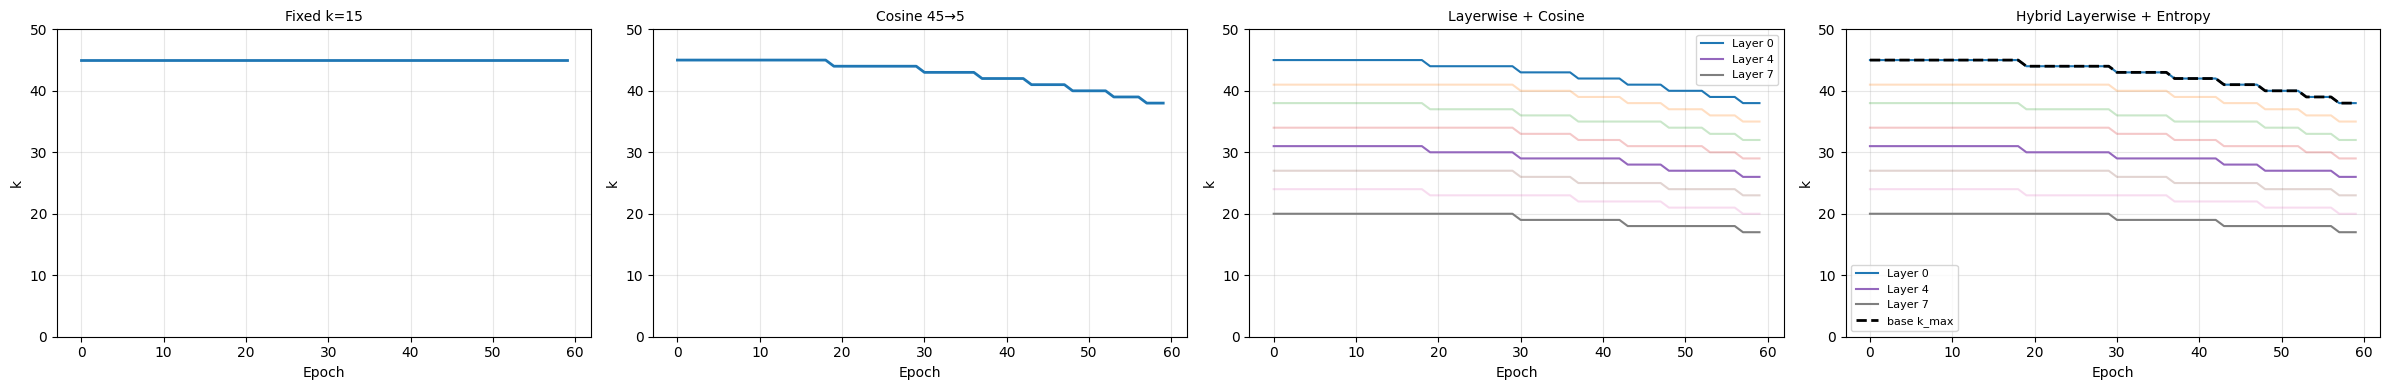

Saved to /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/k_scheduling_strategies.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 4))

schedule_examples = [
    dict(schedule_type='fixed',  per_layer_mode='uniform',      adaptive_mode='none',    title='Fixed k=15'),
    dict(schedule_type='cosine', per_layer_mode='uniform',      adaptive_mode='none',    title='Cosine 45→5'),
    dict(schedule_type='cosine', per_layer_mode='linear_decay', adaptive_mode='none',    title='Layerwise + Cosine'),
    dict(schedule_type='cosine', per_layer_mode='linear_decay', adaptive_mode='entropy', title='Hybrid Layerwise + Entropy'),
]

for ax, cfg in zip(axes, schedule_examples):
    sched = KScheduler(
        k_max=45, k_min=5, total_epochs=200, num_layers=8,
        schedule_type=cfg['schedule_type'],
        per_layer_mode=cfg['per_layer_mode'],
        adaptive_mode=cfg['adaptive_mode'],
        warmup_epochs=5,
        deepest_layer_ratio=0.45,
        adaptive_floor_ratio=0.35,
        entropy_alpha=1.25,
    )
    sched.plot_schedule(ax=ax, epochs_to_show=60)
    ax.set_title(cfg['title'], fontsize=10)
    ax.set_ylim(0, 50)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'k_scheduling_strategies.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")


## 6. Dataset Loading

This section loads the three LRGB datasets used in this practical
- **Peptides-func**
- **Peptides-struct**
- **PascalVOC-SP**

For **PascalVOC-SP**, the notebook follows the paper's protocol
- load the official **train** split
- load the official **val** split
- split that **val** set **50:50** into a new **validation** and **test** set
- stratify by the **majority non-background node label** of each graph


In [ ]:
def majority_non_background_label(data, background_label=0):
    labels = data.y.view(-1).detach().cpu().numpy()
    non_background = labels[labels != background_label]
    if len(non_background) == 0:
        return int(np.bincount(labels).argmax())
    return int(np.bincount(non_background).argmax())

def get_pascal_split_indices(raw_val_dataset, split_dir=SPLIT_DIR, random_state=SEED):
    split_path = os.path.join(split_dir, 'pascal_voc_sp_val_test_split.json')
    if os.path.exists(split_path):
        with open(split_path, 'r') as f:
            obj = json.load(f)
        return obj['val_indices'], obj['test_indices']

    indices = np.arange(len(raw_val_dataset))
    meta_labels = [majority_non_background_label(raw_val_dataset[i]) for i in indices]
    val_idx, test_idx = train_test_split(
        indices,
        test_size=0.5,
        random_state=random_state,
        stratify=meta_labels,
    )

    obj = {
        'dataset_name': 'PascalVOC-SP',
        'random_state': random_state,
        'val_indices': sorted(val_idx.tolist()),
        'test_indices': sorted(test_idx.tolist()),
        'policy': 'original val split divided 50:50 using majority non-background node-label stratification'
    }
    with open(split_path, 'w') as f:
        json.dump(obj, f, indent=2)
    return obj['val_indices'], obj['test_indices']

def load_lrgb_dataset(dataset_name, root=DATA_DIR):
    print(f"Loading {dataset_name}...")

    train_dataset = LRGBDataset(root=root, name=dataset_name, split='train')
    if dataset_name == 'PascalVOC-SP':
        raw_val_dataset = LRGBDataset(root=root, name=dataset_name, split='val')
        val_indices, test_indices = get_pascal_split_indices(raw_val_dataset)
        val_dataset = Subset(raw_val_dataset, val_indices)
        test_dataset = Subset(raw_val_dataset, test_indices)
    else:
        val_dataset = LRGBDataset(root=root, name=dataset_name, split='val')
        test_dataset = LRGBDataset(root=root, name=dataset_name, split='test')

    sample = train_dataset[0]
    num_node_feats = sample.x.size(1)
    num_edge_feats = sample.edge_attr.size(1) if sample.edge_attr is not None else 0

    if 'func' in dataset_name.lower():
        nc = sample.y.size(1) if sample.y.dim() > 1 else 10
        tt, mn, lt = 'graph', 'AP', 'bce'
    elif 'struct' in dataset_name.lower():
        nc = sample.y.size(1) if sample.y.dim() > 1 else 11
        tt, mn, lt = 'graph', 'MAE', 'l1'
    elif 'pascal' in dataset_name.lower():
        nc, tt, mn, lt = 21, 'node', 'F1', 'ce_weighted'
    else:
        raise ValueError(f"Unsupported dataset_name: {dataset_name}")

    def get_stats_subset(ds, limit=500):
        n = min(limit, len(ds))
        node_counts, edge_counts = [], []
        for i in range(n):
            d = ds[i]
            node_counts.append(d.num_nodes)
            edge_counts.append(d.num_edges)
        return float(np.mean(node_counts)), float(np.mean(edge_counts))

    avg_nodes, avg_edges = get_stats_subset(train_dataset, limit=500)

    info = {
        'name': dataset_name,
        'num_node_features': num_node_feats,
        'num_edge_features': num_edge_feats,
        'num_classes': nc,
        'task_type': tt,
        'metric_name': mn,
        'loss_type': lt,
        'num_train': len(train_dataset),
        'num_val': len(val_dataset),
        'num_test': len(test_dataset),
        'avg_nodes': avg_nodes,
        'avg_edges': avg_edges,
    }

    print(f"  Train: {info['num_train']} | Val: {info['num_val']} | Test: {info['num_test']}")
    print(f"  Avg nodes: {info['avg_nodes']:.1f} | Avg edges: {info['avg_edges']:.1f}")
    print(f"  Classes: {nc} | Task: {tt} | Metric: {mn}")
    return train_dataset, val_dataset, test_dataset, info


In [ ]:
print("=" * 60)
peptides_func_train, peptides_func_val, peptides_func_test, peptides_func_info = load_lrgb_dataset('Peptides-func')
print()
peptides_struct_train, peptides_struct_val, peptides_struct_test, peptides_struct_info = load_lrgb_dataset('Peptides-struct')
print()
pascal_train, pascal_val, pascal_test, pascal_info = load_lrgb_dataset('PascalVOC-SP')
print()
print("=" * 60)
print("All datasets loaded!")


Loading Peptides-func...
  Train: 10873 | Val: 2331 | Test: 2331
  Avg nodes: 151.4 | Avg edges: 307.8
  Classes: 10 | Task: graph | Metric: AP

Loading Peptides-struct...
  Train: 10873 | Val: 2331 | Test: 2331
  Avg nodes: 151.4 | Avg edges: 307.8
  Classes: 11 | Task: graph | Metric: MAE

Loading PascalVOC-SP...
  Train: 8498 | Val: 714 | Test: 714
  Avg nodes: 479.2 | Avg edges: 2709.7
  Classes: 21 | Task: node | Metric: F1

All datasets loaded!


## 7. Training Pipeline


In [ ]:
def compute_average_precision(predictions, targets):
    preds = torch.sigmoid(predictions).detach().cpu().numpy()
    tgts = targets.detach().cpu().numpy()
    aps = [average_precision_score(tgts[:, i], preds[:, i])
           for i in range(tgts.shape[1]) if tgts[:, i].sum() > 0]
    return 100.0 * (np.mean(aps) if aps else 0.0)

def compute_mae(predictions, targets):
    return F.l1_loss(predictions, targets).item()

def compute_weighted_f1(predictions, targets, num_classes):
    pred = predictions.argmax(dim=1).detach().cpu().numpy()
    true = targets.detach().cpu().numpy()
    return 100.0 * f1_score(true, pred, average='weighted', zero_division=0)

def compute_class_weights(dataset, num_classes):
    counts = torch.zeros(num_classes)
    for i in range(len(dataset)):
        data = dataset[i]
        for label in data.y.view(-1):
            if 0 <= label < num_classes:
                counts[label.long().item()] += 1
    total = counts.sum()
    w = total / (num_classes * counts.clamp(min=1))
    return w / w.sum() * num_classes


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader as PyGDataLoader

def compute_average_precision(predictions, targets):
    preds = torch.sigmoid(predictions).detach().cpu().numpy()
    tgts = targets.detach().cpu().numpy()
    aps = [average_precision_score(tgts[:, i], preds[:, i])
           for i in range(tgts.shape[1]) if tgts[:, i].sum() > 0]
    return 100.0 * (np.mean(aps) if aps else 0.0)
def compute_mae(predictions, targets):
    return F.l1_loss(predictions, targets).item()

def compute_weighted_f1(predictions, targets, num_classes):
    pred = predictions.argmax(dim=1).detach().cpu().numpy()
    true = targets.detach().cpu().numpy()
    return 100.0 * f1_score(true, pred, average='weighted', zero_division=0)

def compute_class_weights(dataset, num_classes):
    counts = torch.zeros(num_classes)
    for i in range(len(dataset)):
        data = dataset[i]
        for label in data.y.view(-1):
            if 0 <= label < num_classes:
                counts[label.long().item()] += 1
    total = counts.sum()
    w = total / (num_classes * counts.clamp(min=1))
    return w / w.sum() * num_classes

def make_loader(dataset, batch_size, shuffle=False, num_workers=2):
    return PyGDataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(num_workers > 0),
    )

def train_one_epoch(model, train_loader, optimizer, scheduler, loss_type,
                    current_k_plan=None, class_weights=None):
    model.train()
    total_loss, num_batches = 0.0, 0
    epoch_entropies = []
    epoch_query_k = []
    epoch_layer_kmax = []

    for batch_data in train_loader:
        batch_data = batch_data.to(device)
        optimizer.zero_grad()

        predictions, layer_infos = model(batch_data, current_k_plan=current_k_plan)

        epoch_entropies.append([
            info.get('attention_entropy', torch.tensor(0.0)).item() if isinstance(info.get('attention_entropy', None), torch.Tensor)
            else float(info.get('attention_entropy', 0.0))
            for info in layer_infos
        ])
        epoch_query_k.append([float(info.get('query_k_mean', info.get('effective_k', 0.0))) for info in layer_infos])
        epoch_layer_kmax.append([float(info.get('query_k_max', 0.0)) for info in layer_infos])

        if loss_type == 'bce':
            loss = F.binary_cross_entropy_with_logits(predictions, batch_data.y.float())
        elif loss_type == 'l1':
            loss = F.l1_loss(predictions, batch_data.y.float())
        elif loss_type == 'ce_weighted':
            target = batch_data.y.long().view(-1)
            loss = F.cross_entropy(
                predictions, target,
                weight=class_weights.to(device) if class_weights is not None else None
            )
        else:
            loss = F.cross_entropy(predictions, batch_data.y.long())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1

    if scheduler is not None:
        scheduler.step()

    avg_entropies = np.mean(epoch_entropies, axis=0).tolist() if epoch_entropies else []
    avg_query_k = np.mean(epoch_query_k, axis=0).tolist() if epoch_query_k else []
    avg_layer_kmax = np.mean(epoch_layer_kmax, axis=0).tolist() if epoch_layer_kmax else []
    return total_loss / max(num_batches, 1), avg_entropies, avg_query_k, avg_layer_kmax


@torch.no_grad()
def evaluate(model, data_loader, dataset_info, current_k_plan=None, class_weights=None):
    model.eval()
    all_preds, all_tgts = [], []
    total_loss, num_batches = 0.0, 0

    for batch_data in data_loader:
        batch_data = batch_data.to(device)
        predictions, _ = model(batch_data, current_k_plan=current_k_plan)
        all_preds.append(predictions)
        all_tgts.append(batch_data.y)

        if dataset_info['loss_type'] == 'bce':
            loss = F.binary_cross_entropy_with_logits(predictions, batch_data.y.float())
        elif dataset_info['loss_type'] == 'l1':
            loss = F.l1_loss(predictions, batch_data.y.float())
        elif dataset_info['loss_type'] == 'ce_weighted':
            loss = F.cross_entropy(
                predictions, batch_data.y.long().view(-1),
                weight=class_weights.to(device) if class_weights is not None else None
            )
        else:
            loss = F.cross_entropy(predictions, batch_data.y.long())
        total_loss += loss.item()
        num_batches += 1

    all_preds = torch.cat(all_preds, 0)
    all_tgts = torch.cat(all_tgts, 0)
    avg_loss = total_loss / max(num_batches, 1)

    m = dataset_info['metric_name']
    if m == 'AP':
        metric = compute_average_precision(all_preds, all_tgts)
    elif m == 'MAE':
        metric = compute_mae(all_preds, all_tgts.float())
    elif m == 'F1':
        metric = compute_weighted_f1(all_preds, all_tgts, dataset_info['num_classes'])
    else:
        metric = avg_loss
    return metric, avg_loss

In [ ]:
def run_experiment(dataset_info, train_dataset, val_dataset, test_dataset, config, verbose=True):
    train_loader = make_loader(train_dataset, batch_size=config['batch_size'], shuffle=True, num_workers=config.get('num_workers', 2))
    val_loader = make_loader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config.get('num_workers', 2))
    test_loader = make_loader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=config.get('num_workers', 2))

    model = GraphGPSModel(
        num_node_features=dataset_info['num_node_features'],
        num_edge_features=dataset_info['num_edge_features'],
        num_classes=dataset_info['num_classes'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        num_heads=config['num_heads'],
        k=config['k'],
        dropout=config['dropout'],
        attention_dropout=config['attention_dropout'],
        task_type=dataset_info['task_type'],
        graph_pooling=config.get('graph_pooling', 'mean'),
        num_output_layers=config.get('num_output_layers', 2),
        attention_backend=config.get('attention_backend', DEFAULT_ATTENTION_BACKEND),
    ).to(device)

    num_params = model.count_parameters()
    if verbose:
        print(
            f"Params: {num_params:,} | backend: {config.get('attention_backend', DEFAULT_ATTENTION_BACKEND)} "
            f"| schedule: {config.get('k_schedule', 'fixed')} "
            f"| per_layer: {config.get('per_layer_mode', 'uniform')} "
            f"| adaptive: {config.get('adaptive_mode', 'none')}"
        )

    class_weights = compute_class_weights(train_dataset, dataset_info['num_classes']) if dataset_info['loss_type'] == 'ce_weighted' else None
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config.get('weight_decay', 0.0))

    warmup_epochs = config.get('warmup_epochs', 10)

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / max(warmup_epochs, 1)
        return 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / max(config['num_epochs'] - warmup_epochs, 1)))

    lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    k_sched = KScheduler(
        k_max=config.get('k_max', config['k']),
        k_min=config.get('k_min', config['k']),
        total_epochs=config['num_epochs'],
        num_layers=config['num_layers'],
        schedule_type=config.get('k_schedule', 'fixed'),
        warmup_epochs=config.get('k_warmup_epochs', 0),
        step_interval=config.get('step_interval', 20),
        step_gamma=config.get('step_gamma', 0.5),
        per_layer_mode=config.get('per_layer_mode', 'uniform'),
        deepest_layer_ratio=config.get('deepest_layer_ratio', 0.45),
        adaptive_mode=config.get('adaptive_mode', 'none'),
        adaptive_floor_ratio=config.get('adaptive_floor_ratio', 0.35),
        entropy_alpha=config.get('entropy_alpha', 1.25),
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_metric': [],
        'k_values': [],
        'epoch_times': [],
        'learning_rates': [],
        'layer_entropies': [],
        'effective_k_per_layer': [],
        'query_k_per_layer': [],
        'scheduled_layer_kmax': [],
    }

    higher_better = dataset_info['metric_name'] != 'MAE'
    best_val = float('-inf') if higher_better else float('inf')
    best_state = None
    best_k_plan = None
    best_epoch = -1
    patience_ctr = 0
    patience = config.get('patience', 50)
    min_delta = config.get('min_delta', 0.0)

    for epoch in range(config['num_epochs']):
        t0 = time.time()
        current_k_plan = k_sched.get_k_plans(epoch)

        train_loss, layer_ent, avg_query_k, avg_layer_kmax = train_one_epoch(
            model, train_loader, optimizer, lr_scheduler, dataset_info['loss_type'],
            current_k_plan=current_k_plan, class_weights=class_weights
        )
        val_metric, val_loss = evaluate(
            model, val_loader, dataset_info,
            current_k_plan=current_k_plan, class_weights=class_weights
        )
        dt = time.time() - t0

        display_k = [plan['k_max'] if isinstance(plan, dict) else plan for plan in current_k_plan]
        history['k_values'].append(float(np.mean(display_k)))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_metric'].append(val_metric)
        history['epoch_times'].append(dt)
        history['learning_rates'].append(optimizer.param_groups[0]['lr'])
        history['layer_entropies'].append(layer_ent)
        history['effective_k_per_layer'].append(display_k)
        history['query_k_per_layer'].append(avg_query_k)
        history['scheduled_layer_kmax'].append(avg_layer_kmax)

        if higher_better:
            improved = val_metric > best_val + min_delta
        else:
            improved = val_metric < best_val - min_delta

        if improved:
            best_val = val_metric
            best_state = deepcopy(model.state_dict())
            best_k_plan = deepcopy(current_k_plan)
            best_epoch = epoch + 1
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch == 0 or (epoch + 1) % 10 == 0 or epoch == config['num_epochs'] - 1):
            print(
                f"Epoch {epoch+1:03d} | TrainLoss {train_loss:.4f} "
                f"| Val {dataset_info['metric_name']} {val_metric:.4f} "
                f"| k {display_k[0]}...{display_k[-1]} | {dt:.1f}s"
            )

        if config.get('use_early_stopping', False) and patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1} | best epoch {best_epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metric, test_loss = evaluate(
        model, test_loader, dataset_info,
        current_k_plan=best_k_plan, class_weights=class_weights
    )

    return {
        'test_metric': test_metric,
        'test_loss': test_loss,
        'best_val_metric': best_val,
        'best_epoch': best_epoch,
        'epochs_completed': len(history['train_loss']),
        'num_params': num_params,
        'metric_name': dataset_info['metric_name'],
        'history': history,
        'config': deepcopy(config),
        'total_time': float(np.sum(history['epoch_times'])),
        'backend': config.get('attention_backend', DEFAULT_ATTENTION_BACKEND),
    }

## 8. Experiments (3-Seed Sweep)

**3-seed sweep** (seeds 0, 1, 2) that produces mean ± std for all methods across all datasets.
The sweep runs in the cells below, then a bridge cell reconstructs the
per-method result dictionaries so all downstream plotting and saving works
unchanged.


In [ ]:
# Experiment configuration — SPLIT ->  Peptides vs PascalVOC-SP



DEFAULT_ATTENTION_BACKEND = "dense"

# ── Peptides (graph-level)
PEPTIDES_CONFIG = {
    'hidden_dim': 52,
    'num_layers': 8,
    'num_heads': 4,
    'k': 15,
    'dropout': 0.1,
    'attention_dropout': 0.5,
    'learning_rate': 0.001,
    'weight_decay': 0.0,
    'num_epochs': 50,
    'warmup_epochs': 5,
    'k_warmup_epochs': 3,
    'batch_size': 32,
    'num_workers': 2,
    'graph_pooling': 'mean',
    'num_output_layers': 2,
    'use_early_stopping': True,
    'patience': 12,
    'min_delta': 0.0,
    'attention_backend': DEFAULT_ATTENTION_BACKEND,
}

# ── PascalVOC-SP (node-level)
PASCAL_CONFIG = {
    'hidden_dim': 52,
    'num_layers': 8,
    'num_heads': 4,
    'k': 15,
    'dropout': 0.1,
    'attention_dropout': 0.5,
    'learning_rate': 0.0005,          # halved for more stable node-level optimisation
    'weight_decay': 0.0,
    'num_epochs': 60,
    'warmup_epochs': 10,              # up from 5 - more LR warmup for stability
    'k_warmup_epochs': 10,            # up from 3 - stabilise before k decay
    'batch_size': 8,
    'num_workers': 2,
    'graph_pooling': 'mean',
    'num_output_layers': 2,
    'use_early_stopping': True,
    'patience': 25,                   # up from 12 - F1 is noisy, give room
    'min_delta': 0.0,
    'attention_backend': DEFAULT_ATTENTION_BACKEND,
}

# ── Fast-dev configs ──
FAST_DEV_PEPTIDES = {**PEPTIDES_CONFIG, 'num_epochs': 8, 'warmup_epochs': 2, 'k_warmup_epochs': 1, 'patience': 4}
FAST_DEV_PASCAL   = {**PASCAL_CONFIG,   'num_epochs': 8, 'warmup_epochs': 2, 'k_warmup_epochs': 1, 'patience': 4}

# ── Run mode toggle ──
RUN_MODE = 'main'   # 'main' or 'fast_dev'

GRAPH_RUN_CONFIG = FAST_DEV_PEPTIDES if RUN_MODE == 'fast_dev' else PEPTIDES_CONFIG
NODE_RUN_CONFIG  = FAST_DEV_PASCAL   if RUN_MODE == 'fast_dev' else PASCAL_CONFIG

# ── Peptides k-strategies ──
def get_peptides_configs(base):
    return {
        'fixed_k15': {
            **base,
            'k_schedule': 'fixed',
            'per_layer_mode': 'uniform',
            'adaptive_mode': 'none',
            'k': 15, 'k_max': 15, 'k_min': 15,
        },
        'cosine_45to5': {
            **base,
            'k_schedule': 'cosine',
            'per_layer_mode': 'uniform',
            'adaptive_mode': 'none',
            'k': 45, 'k_max': 45, 'k_min': 5,
        },
        'layerwise_cosine_45to5': {
            **base,
            'k_schedule': 'cosine',
            'per_layer_mode': 'linear_decay',
            'deepest_layer_ratio': 0.45,
            'adaptive_mode': 'none',
            'k': 45, 'k_max': 45, 'k_min': 5,
        },
        'hybrid_entropy_layerwise_45to5': {
            **base,
            'k_schedule': 'cosine',
            'per_layer_mode': 'linear_decay',
            'deepest_layer_ratio': 0.45,
            'adaptive_mode': 'entropy',
            'adaptive_floor_ratio': 0.35,
            'entropy_alpha': 1.25,
            'k': 45, 'k_max': 45, 'k_min': 5,
        },
    }

# ── PascalVOC-SP k-strategies - tuned range 30→10 ──
def get_pascal_configs(base):
    return {
        'fixed_k15': {
            **base,
            'k_schedule': 'fixed',
            'per_layer_mode': 'uniform',
            'adaptive_mode': 'none',
            'k': 15, 'k_max': 15, 'k_min': 15,
        },
        'cosine_30to10': {
            **base,
            'k_schedule': 'cosine',
            'per_layer_mode': 'uniform',
            'adaptive_mode': 'none',
            'k': 30, 'k_max': 30, 'k_min': 10,
        },
        'layerwise_cosine_30to10': {
            **base,
            'k_schedule': 'cosine',
            'per_layer_mode': 'linear_decay',
            'deepest_layer_ratio': 0.45,
            'adaptive_mode': 'none',
            'k': 30, 'k_max': 30, 'k_min': 10,
        },
        'hybrid_entropy_layerwise_30to10': {
            **base,
            'k_schedule': 'cosine',
            'per_layer_mode': 'linear_decay',
            'deepest_layer_ratio': 0.45,
            'adaptive_mode': 'entropy',
            'adaptive_floor_ratio': 0.35,
            'entropy_alpha': 1.25,
            'k': 30, 'k_max': 30, 'k_min': 10,
        },
    }

# ── Print summary ──
print(f"RUN_MODE = {RUN_MODE}")
print(f"\n{'='*60}")
print("PEPTIDES (graph-level) — same as Run 1:")
print(f"  epochs={GRAPH_RUN_CONFIG['num_epochs']}, patience={GRAPH_RUN_CONFIG['patience']}, "
      f"lr={GRAPH_RUN_CONFIG['learning_rate']}, k_warmup={GRAPH_RUN_CONFIG['k_warmup_epochs']}")
for name, cfg in get_peptides_configs(GRAPH_RUN_CONFIG).items():
    print(f"  {name}: schedule={cfg['k_schedule']}, k={cfg['k_max']}→{cfg['k_min']}, "
          f"per_layer={cfg['per_layer_mode']}, adaptive={cfg['adaptive_mode']}")

print(f"\n{'='*60}")
print("PASCAL VOC-SP (node-level) — tuned for the next run:")
print(f"  epochs={NODE_RUN_CONFIG['num_epochs']}, patience={NODE_RUN_CONFIG['patience']}, "
      f"lr={NODE_RUN_CONFIG['learning_rate']}, k_warmup={NODE_RUN_CONFIG['k_warmup_epochs']}")
for name, cfg in get_pascal_configs(NODE_RUN_CONFIG).items():
    print(f"  {name}: schedule={cfg['k_schedule']}, k={cfg['k_max']}→{cfg['k_min']}, "
          f"per_layer={cfg['per_layer_mode']}, adaptive={cfg['adaptive_mode']}")

RUN_MODE = main

PEPTIDES (graph-level) — same as Run 1:
  epochs=50, patience=12, lr=0.001, k_warmup=3
  fixed_k15: schedule=fixed, k=15→15, per_layer=uniform, adaptive=none
  cosine_45to5: schedule=cosine, k=45→5, per_layer=uniform, adaptive=none
  layerwise_cosine_45to5: schedule=cosine, k=45→5, per_layer=linear_decay, adaptive=none
  hybrid_entropy_layerwise_45to5: schedule=cosine, k=45→5, per_layer=linear_decay, adaptive=entropy

PASCAL VOC-SP (node-level) — tuned for the next run:
  epochs=60, patience=25, lr=0.0005, k_warmup=10
  fixed_k15: schedule=fixed, k=15→15, per_layer=uniform, adaptive=none
  cosine_30to10: schedule=cosine, k=30→10, per_layer=uniform, adaptive=none
  layerwise_cosine_30to10: schedule=cosine, k=30→10, per_layer=linear_decay, adaptive=none
  hybrid_entropy_layerwise_30to10: schedule=cosine, k=30→10, per_layer=linear_decay, adaptive=entropy


### 8.1 Profiling Utilities and Seed Control


In [ ]:
import gc
import os
import time
import json
import math
import random
import itertools
from copy import deepcopy

import numpy as np
import pandas as pd
import torch
from torch_geometric.loader import DataLoader as PyGDataLoader

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

CURRENT_GLOBAL_SEED = None

def set_global_seed(seed: int):
    global CURRENT_GLOBAL_SEED
    CURRENT_GLOBAL_SEED = int(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int):
    base = CURRENT_GLOBAL_SEED if CURRENT_GLOBAL_SEED is not None else 0
    worker_seed = (base + worker_id) % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

def make_loader(dataset, batch_size, shuffle=False, num_workers=2):
    """
    Patches the loader factory so repeated runs remain reproducible across seeds.
    """
    generator = None
    worker_init = None

    if CURRENT_GLOBAL_SEED is not None:
        generator = torch.Generator()
        generator.manual_seed(CURRENT_GLOBAL_SEED + (17 if shuffle else 23))
        worker_init = seed_worker

    return PyGDataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(num_workers > 0),
        worker_init_fn=worker_init,
        generator=generator,
    )

def run_experiment_profiled(dataset_info, train_dataset, val_dataset, test_dataset, config, seed=0, verbose=True):
    set_global_seed(seed)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    wall_t0 = time.time()
    results = run_experiment(
        dataset_info=dataset_info,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        config=deepcopy(config),
        verbose=verbose,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    wall_time = time.time() - wall_t0

    profiled = deepcopy(results)
    profiled["seed"] = int(seed)
    profiled["wall_time_seconds"] = float(wall_time)
    profiled["gpu_peak_allocated_mb"] = (
        float(torch.cuda.max_memory_allocated() / 1024**2) if torch.cuda.is_available() else np.nan
    )
    profiled["gpu_peak_reserved_mb"] = (
        float(torch.cuda.max_memory_reserved() / 1024**2) if torch.cuda.is_available() else np.nan
    )

    return profiled

print("Seed/profiling utilities loaded.")


Seed/profiling utilities loaded.


### 8.2 KScheduler Pace Patch


In [ ]:
# Patches KScheduler to support schedule_power (Optional)
# schedule_power = 1.0  -> current behaviour
# schedule_power < 1.0  -> faster early decay
# schedule_power > 1.0  -> slower early decay, sharper late decay

if not hasattr(KScheduler, "_pace_patch_applied"):
    _orig_init = KScheduler.__init__
    _orig_base_k = KScheduler._base_k

    def _patched_init(self, *args, schedule_power=1.0, **kwargs):
        _orig_init(self, *args, **kwargs)
        self.schedule_power = float(schedule_power)

    def _patched_base_k(self, epoch):
        if epoch < self.warmup_epochs:
            return self.k_max

        eff_epoch = epoch - self.warmup_epochs
        eff_total = max(self.total_epochs - self.warmup_epochs, 1)
        power = float(getattr(self, "schedule_power", 1.0))

        if self.schedule_type == "cosine":
            progress = min(eff_epoch / eff_total, 1.0)
            progress = progress ** power
            k = self.k_min + 0.5 * (self.k_max - self.k_min) * (1 + math.cos(math.pi * progress))
            return max(self.k_min, int(round(k)))

        return _orig_base_k(self, epoch)

    KScheduler.__init__ = _patched_init
    KScheduler._base_k = _patched_base_k
    KScheduler._pace_patch_applied = True

print("KScheduler pace patch ready. We can now pass schedule_power in config.")


KScheduler pace patch ready. We can now pass schedule_power in config.


### 8.3 Dataset Registry


In [ ]:
#  Dataset Registry + helper utilities
import ast

DATASET_REGISTRY = {
    "peptides_func": {
        "display_name": "Peptides-Func",
        "info": peptides_func_info,
        "train": peptides_func_train,
        "val": peptides_func_val,
        "test": peptides_func_test,
        "base_config": GRAPH_RUN_CONFIG,
        "config_builder": get_peptides_configs,
        "metric_name": "AP",
        "higher_is_better": True,
    },
    "peptides_struct": {
        "display_name": "Peptides-Struct",
        "info": peptides_struct_info,
        "train": peptides_struct_train,
        "val": peptides_struct_val,
        "test": peptides_struct_test,
        "base_config": GRAPH_RUN_CONFIG,
        "config_builder": get_peptides_configs,
        "metric_name": "MAE",
        "higher_is_better": False,
    },
    "pascal_voc_sp": {
        "display_name": "PascalVOC-SP",
        "info": pascal_info,
        "train": pascal_train,
        "val": pascal_val,
        "test": pascal_test,
        "base_config": NODE_RUN_CONFIG,
        "config_builder": get_pascal_configs,
        "metric_name": "F1",
        "higher_is_better": True,
    },
}

METHOD_LABELS = {
    "fixed_k15": "Fixed k=15",
    "cosine_45to5": "Cosine 45→5",
    "layerwise_cosine_45to5": "Layerwise 45→5",
    "hybrid_entropy_layerwise_45to5": "Hybrid 45→5",
    "cosine_30to10": "Cosine 30→10",
    "layerwise_cosine_30to10": "Layerwise 30→10",
    "hybrid_entropy_layerwise_30to10": "Hybrid 30→10",
}

def format_mean_std(mean, std, decimals=4):
    if pd.isna(std):
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"

def format_seconds(sec):
    return f"{sec:.1f}s"

def format_mb(mb):
    return f"{mb:.1f} MB"

def get_default_method_names(dataset_key):
    reg = DATASET_REGISTRY[dataset_key]
    return list(reg["config_builder"](deepcopy(reg["base_config"])).keys())

# ----------------------------
# resumable checkpoint helpers
# ----------------------------
def _checkpoint_base_path(stem: str):
    return os.path.join(RESULTS_DIR, stem)

def _checkpoint_pickle_path(stem: str):
    return _checkpoint_base_path(stem) + ".pkl"

def _checkpoint_csv_path(stem: str):
    return _checkpoint_base_path(stem) + ".csv"

def _ensure_parent_dir(path: str):
    os.makedirs(os.path.dirname(path), exist_ok=True)

def _load_checkpoint_df(stem: str):
    pkl_path = _checkpoint_pickle_path(stem)
    csv_path = _checkpoint_csv_path(stem)

    if os.path.exists(pkl_path):
        return pd.read_pickle(pkl_path)

    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # Best-effort recovery if only CSV is present
        if "history" in df.columns:
            def _parse_history(x):
                if isinstance(x, dict):
                    return x
                if pd.isna(x):
                    return {}
                if isinstance(x, str):
                    try:
                        return json.loads(x)
                    except Exception:
                        try:
                            return ast.literal_eval(x)
                        except Exception:
                            return {}
                return {}
            df["history"] = df["history"].apply(_parse_history)
        return df

    return pd.DataFrame()

def _save_checkpoint_df(df: pd.DataFrame, stem: str, key_cols):
    if len(df) == 0:
        return df

    out = df.copy()
    if key_cols:
        out = out.drop_duplicates(subset=key_cols, keep="last").reset_index(drop=True)

    pkl_path = _checkpoint_pickle_path(stem)
    csv_path = _checkpoint_csv_path(stem)
    _ensure_parent_dir(pkl_path)

    out.to_pickle(pkl_path)

    csv_out = out.copy()
    if "history" in csv_out.columns:
        csv_out["history"] = csv_out["history"].apply(
            lambda x: json.dumps(x) if isinstance(x, (dict, list)) else x
        )
    csv_out.to_csv(csv_path, index=False)
    return out

def _completed_key_set(df: pd.DataFrame, key_cols):
    if df is None or len(df) == 0:
        return set()
    keys = set()
    for _, row in df[key_cols].iterrows():
        key = []
        for col in key_cols:
            val = row[col]
            if col == "seed" and not pd.isna(val):
                try:
                    val = int(val)
                except Exception:
                    pass
            key.append(val)
        keys.add(tuple(key))
    return keys

def _refresh_three_seed_aggregate_from_checkpoints():
    stems = [
        "peptides_func_three_seed_raw_runs",
        "peptides_struct_three_seed_raw_runs",
        "pascal_voc_sp_three_seed_raw_runs",
    ]
    dfs = []
    for stem in stems:
        df = _load_checkpoint_df(stem)
        if len(df) > 0:
            dfs.append(df)
    if len(dfs) == 0:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

print("Dataset registry and resumable checkpoint helpers ready.")

Dataset registry and resumable checkpoint helpers ready.


### 8.4 Three-Seed Sweep

Runs all 4 methods × 3 datasets × 3 seeds = 36 training runs.
This version checkpoints after every completed seed and skips finished seed-runs on resume.

In [ ]:
def run_multiseed_for_dataset(
    dataset_key,
    method_names=None,
    seeds=(0, 1, 2),
    verbose=False,
    resume=True,
    checkpoint_stem=None,
):
    reg = DATASET_REGISTRY[dataset_key]
    config_dict = reg["config_builder"](deepcopy(reg["base_config"]))

    if method_names is None:
        method_names = list(config_dict.keys())

    if checkpoint_stem is None:
        checkpoint_stem = f"{dataset_key}_three_seed_raw_runs"

    key_cols = ["dataset_key", "method_name", "seed"]
    existing_df = _load_checkpoint_df(checkpoint_stem) if resume else pd.DataFrame()
    existing_df = _save_checkpoint_df(existing_df, checkpoint_stem, key_cols) if len(existing_df) > 0 else existing_df
    completed = _completed_key_set(existing_df, key_cols)

    rows = existing_df.to_dict("records") if len(existing_df) > 0 else []

    if len(completed) > 0:
        print(f"Loaded checkpoint for {reg['display_name']}: {len(completed)} completed seed-runs found.")

    for method_name in method_names:
        cfg = deepcopy(config_dict[method_name])

        print(f"\n=== {reg['display_name']} | {method_name} ===")
        for seed in seeds:
            key = (dataset_key, method_name, int(seed))

            if key in completed:
                print(f"  -> seed {seed} already complete, skipping")
                continue

            print(f"  -> seed {seed} running")
            out = run_experiment_profiled(
                dataset_info=reg["info"],
                train_dataset=reg["train"],
                val_dataset=reg["val"],
                test_dataset=reg["test"],
                config=cfg,
                seed=seed,
                verbose=verbose,
            )

            row = {
                "dataset_key": dataset_key,
                "dataset": reg["display_name"],
                "method_name": method_name,
                "method": METHOD_LABELS.get(method_name, method_name),
                "seed": int(seed),
                "metric_name": out["metric_name"],
                "test_metric": out["test_metric"],
                "best_val_metric": out["best_val_metric"],
                "best_epoch": out["best_epoch"],
                "epochs_completed": out["epochs_completed"],
                "num_params": out["num_params"],
                "train_time_seconds": out["total_time"],
                "wall_time_seconds": out["wall_time_seconds"],
                "gpu_peak_allocated_mb": out["gpu_peak_allocated_mb"],
                "gpu_peak_reserved_mb": out["gpu_peak_reserved_mb"],
                "k_schedule": cfg.get("k_schedule", "fixed"),
                "per_layer_mode": cfg.get("per_layer_mode", "uniform"),
                "adaptive_mode": cfg.get("adaptive_mode", "none"),
                "k_max": cfg.get("k_max", cfg["k"]),
                "k_min": cfg.get("k_min", cfg["k"]),
                "k_warmup_epochs": cfg.get("k_warmup_epochs", 0),
                "warmup_epochs": cfg.get("warmup_epochs", 0),
                "patience": cfg.get("patience", None),
                "schedule_power": cfg.get("schedule_power", 1.0),
                "learning_rate": cfg.get("learning_rate", None),
                "backend": out.get("backend", cfg.get("attention_backend", "dense")),
                "history": out.get("history", {}),
            }
            rows.append(row)

            current_df = pd.DataFrame(rows)
            current_df = _save_checkpoint_df(current_df, checkpoint_stem, key_cols)
            rows = current_df.to_dict("records")
            completed = _completed_key_set(current_df, key_cols)

            print(
                f"     saved checkpoint -> {checkpoint_stem} "
                f"({len(current_df)} completed seed-runs total)"
            )

    final_df = _load_checkpoint_df(checkpoint_stem)
    if len(final_df) == 0:
        final_df = pd.DataFrame(rows)
    final_df = _save_checkpoint_df(final_df, checkpoint_stem, key_cols)

    return final_df

def summarise_multiseed_metrics(df):
    grouped = (
        df.groupby(["dataset", "method", "metric_name"], as_index=False)
          .agg(
              mean_test=("test_metric", "mean"),
              std_test=("test_metric", "std"),
              mean_val=("best_val_metric", "mean"),
              std_val=("best_val_metric", "std"),
              mean_best_epoch=("best_epoch", "mean"),
              std_best_epoch=("best_epoch", "std"),
              mean_epochs_completed=("epochs_completed", "mean"),
              std_epochs_completed=("epochs_completed", "std"),
              n=("seed", "count"),
          )
    )

    grouped["test_mean±std"] = grouped.apply(lambda r: format_mean_std(r["mean_test"], r["std_test"], 4), axis=1)
    grouped["val_mean±std"] = grouped.apply(lambda r: format_mean_std(r["mean_val"], r["std_val"], 4), axis=1)
    grouped["best_epoch_mean±std"] = grouped.apply(lambda r: format_mean_std(r["mean_best_epoch"], r["std_best_epoch"], 1), axis=1)
    grouped["epochs_completed_mean±std"] = grouped.apply(lambda r: format_mean_std(r["mean_epochs_completed"], r["std_epochs_completed"], 1), axis=1)

    return grouped[[
        "dataset", "method", "metric_name", "test_mean±std",
        "val_mean±std", "best_epoch_mean±std", "epochs_completed_mean±std", "n"
    ]]

# ---- resumable full three-seed sweep over the main methods ----
SEEDS = (0, 1, 2)

df_func_3seed   = run_multiseed_for_dataset("peptides_func",   seeds=SEEDS, verbose=False, resume=True)
df_struct_3seed = run_multiseed_for_dataset("peptides_struct", seeds=SEEDS, verbose=False, resume=True)
df_pascal_3seed = run_multiseed_for_dataset("pascal_voc_sp",   seeds=SEEDS, verbose=False, resume=True)

df_3seed_all = pd.concat([df_func_3seed, df_struct_3seed, df_pascal_3seed], ignore_index=True)
df_3seed_all = _save_checkpoint_df(df_3seed_all, "three_seed_raw_runs", ["dataset_key", "method_name", "seed"])

three_seed_table = summarise_multiseed_metrics(df_3seed_all)
display(three_seed_table)
three_seed_table.to_csv(os.path.join(RESULTS_DIR, "three_seed_summary_table.csv"), index=False)

print("Saved resumable three-seed checkpoints, combined raw runs, and summary table.")

Loaded checkpoint for Peptides-Func: 12 completed seed-runs found.

=== Peptides-Func | fixed_k15 ===
  -> seed 0 already complete, skipping
  -> seed 1 already complete, skipping
  -> seed 2 already complete, skipping

=== Peptides-Func | cosine_45to5 ===
  -> seed 0 already complete, skipping
  -> seed 1 already complete, skipping
  -> seed 2 already complete, skipping

=== Peptides-Func | layerwise_cosine_45to5 ===
  -> seed 0 already complete, skipping
  -> seed 1 already complete, skipping
  -> seed 2 already complete, skipping

=== Peptides-Func | hybrid_entropy_layerwise_45to5 ===
  -> seed 0 already complete, skipping
  -> seed 1 already complete, skipping
  -> seed 2 already complete, skipping
Loaded checkpoint for Peptides-Struct: 12 completed seed-runs found.

=== Peptides-Struct | fixed_k15 ===
  -> seed 0 already complete, skipping
  -> seed 1 already complete, skipping
  -> seed 2 already complete, skipping

=== Peptides-Struct | cosine_45to5 ===
  -> seed 0 already compl

,dataset,method,metric_name,test_mean±std,val_mean±std,best_epoch_mean±std,epochs_completed_mean±std,n
0,PascalVOC-SP,Cosine 30→10,F1,47.9884 ± 0.9728,47.6385 ± 1.1906,30.7 ± 11.7,52.7 ± 6.7,3
1,PascalVOC-SP,Fixed k=15,F1,47.2283 ± 7.5282,46.8656 ± 7.2009,15.0 ± 24.2,37.3 ± 19.6,3
2,PascalVOC-SP,Hybrid 30→10,F1,50.3542 ± 5.6629,50.0689 ± 5.2096,30.0 ± 25.5,48.7 ± 19.6,3
3,PascalVOC-SP,Layerwise 30→10,F1,49.6250 ± 3.1290,49.2793 ± 3.2734,22.3 ± 18.5,47.3 ± 18.5,3
4,Peptides-Func,Cosine 45→5,AP,61.1350 ± 1.6675,62.5055 ± 0.7750,33.0 ± 5.2,45.0 ± 5.2,3
5,Peptides-Func,Fixed k=15,AP,63.0123 ± 0.6749,64.9314 ± 0.7562,43.7 ± 2.3,50.0 ± 0.0,3
6,Peptides-Func,Hybrid 45→5,AP,61.4472 ± 0.4822,63.0730 ± 0.3264,36.0 ± 2.6,48.0 ± 2.6,3
7,Peptides-Func,Layerwise 45→5,AP,60.7681 ± 0.7396,62.3949 ± 1.3322,33.3 ± 2.5,45.3 ± 2.5,3
8,Peptides-Struct,Cosine 45→5,MAE,0.2784 ± 0.0056,0.2707 ± 0.0059,18.0 ± 4.4,30.0 ± 4.4,3
9,Peptides-Struct,Fixed k=15,MAE,0.2652 ± 0.0039,0.2616 ± 0.0040,44.3 ± 1.2,50.0 ± 0.0,3


Saved resumable three-seed checkpoints, combined raw runs, and summary table.


In [ ]:
#
# Reconstructs original result dicts from saved runs
# This cell rebuilds the annealing_results_* dicts expected by
# the plotting cells. It first tries in-memory 3-seed results,
# then falls back to resumable checkpoints on disk, and finally
# to saved JSON exports if needed.

def _coerce_history_dict(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x):
        return {}
    if isinstance(x, str):
        try:
            return json.loads(x)
        except Exception:
            try:
                return ast.literal_eval(x)
            except Exception:
                return {}
    return {}

def _normalize_result_entry(entry):
    entry = dict(entry)
    return {
        'test_metric': entry.get('test_metric', entry.get('test', np.nan)),
        'best_val_metric': entry.get('best_val_metric', entry.get('val', np.nan)),
        'best_epoch': entry.get('best_epoch', np.nan),
        'epochs_completed': entry.get('epochs_completed', np.nan),
        'num_params': entry.get('num_params', entry.get('params', np.nan)),
        'total_time': entry.get('total_time', entry.get('train_time_seconds', entry.get('time', np.nan))),
        'metric_name': entry.get('metric_name', entry.get('metric', '')),
        'backend': entry.get('backend', 'dense'),
        'wall_time_seconds': entry.get('wall_time_seconds', np.nan),
        'gpu_peak_allocated_mb': entry.get('gpu_peak_allocated_mb', np.nan),
        'gpu_peak_reserved_mb': entry.get('gpu_peak_reserved_mb', np.nan),
        'history': _coerce_history_dict(entry.get('history', {})),
    }

def rebuild_result_dicts_from_sweep(df_all, dataset_key, seed=0):
    # Rebuild the {method_name: results_dict} expected by plotting cells.
    if df_all is None or len(df_all) == 0:
        return {}
    subset = df_all[(df_all['dataset_key'] == dataset_key) & (df_all['seed'] == seed)]
    result_dict = {}
    for _, row in subset.iterrows():
        method_name = row['method_name']
        result_dict[method_name] = _normalize_result_entry(dict(row))
    return result_dict

def _load_result_dict_from_json(dataset_key):
    json_candidates = [
        os.path.join(RESULTS_DIR, 'all_lrgb_results.json'),
        os.path.join(RESULTS_DIR, f'{dataset_key}_results.json'),
    ]

    for path in json_candidates:
        if not os.path.exists(path):
            continue
        try:
            with open(path, 'r') as f:
                payload = json.load(f)
        except Exception as e:
            print(f"Warning: could not read {path}: {e}")
            continue

        # all_lrgb_results.json -> nested by dataset_key
        if isinstance(payload, dict) and dataset_key in payload and isinstance(payload[dataset_key], dict):
            return {
                method_name: _normalize_result_entry(entry)
                for method_name, entry in payload[dataset_key].items()
            }

        # direct dataset result json -> method dict at top level
        if isinstance(payload, dict) and len(payload) > 0:
            if all(isinstance(v, dict) for v in payload.values()):
                return {
                    method_name: _normalize_result_entry(entry)
                    for method_name, entry in payload.items()
                }

    return {}

def _recover_df_3seed_all():
    # 1) already in memory
    if 'df_3seed_all' in globals():
        try:
            if df_3seed_all is not None and len(df_3seed_all) > 0:
                return df_3seed_all
        except Exception:
            pass

    # 2) combined resumable checkpoint
    df = _load_checkpoint_df("three_seed_raw_runs")
    if df is not None and len(df) > 0:
        return df

    # 3) rebuild combined df from per-dataset checkpoints
    df = _refresh_three_seed_aggregate_from_checkpoints()
    if df is not None and len(df) > 0:
        df = _save_checkpoint_df(df, "three_seed_raw_runs", ["dataset_key", "method_name", "seed"])
        return df

    return pd.DataFrame()

df_3seed_all = _recover_df_3seed_all()

if len(df_3seed_all) > 0:
    annealing_results_func   = rebuild_result_dicts_from_sweep(df_3seed_all, 'peptides_func')
    annealing_results_struct = rebuild_result_dicts_from_sweep(df_3seed_all, 'peptides_struct')
    annealing_results_pascal = rebuild_result_dicts_from_sweep(df_3seed_all, 'pascal_voc_sp')
    recovery_source = "3-seed checkpoints / raw runs"
else:
    annealing_results_func   = _load_result_dict_from_json('peptides_func')
    annealing_results_struct = _load_result_dict_from_json('peptides_struct')
    annealing_results_pascal = _load_result_dict_from_json('pascal_voc_sp')
    recovery_source = "saved JSON exports"

print(f"Recovered plotting dictionaries from: {recovery_source}")
for label, rd in [('Peptides-Func', annealing_results_func),
                  ('Peptides-Struct', annealing_results_struct),
                  ('PascalVOC-SP', annealing_results_pascal)]:
    print(f"  {label}: {list(rd.keys())}")


Recovered plotting dictionaries from: 3-seed checkpoints / raw runs
  Peptides-Func: ['fixed_k15', 'cosine_45to5', 'layerwise_cosine_45to5', 'hybrid_entropy_layerwise_45to5']
  Peptides-Struct: ['fixed_k15', 'cosine_45to5', 'layerwise_cosine_45to5', 'hybrid_entropy_layerwise_45to5']
  PascalVOC-SP: ['fixed_k15', 'cosine_30to10', 'layerwise_cosine_30to10', 'hybrid_entropy_layerwise_30to10']


**Reload note.**  
If you reconnect to Colab and the in-memory result variables are gone, rerun the bridge cell above before rerunning the plotting cells. It now rebuilds the plotting dictionaries from saved checkpoints or JSON exports automatically.

## 9. Cross-Dataset Results and Analysis


In [ ]:
print("=" * 110)
print("TABLE 2 STYLE COMPARISON: Paper references vs our patched notebook")
print("=" * 110)

print(f"\n{'Method':<35} {'PascalVOC-SP (F1)':>20} {'Pept-Func (AP)':>18} {'Pept-Struct (MAE)':>20}")
print("-" * 100)

paper = [

    ('GPS+k-MIP (paper)', '39.69', '66.27', '0.2562'),
]
for name, p, f, s in paper:
    print(f"  {name:<33} {p:>20} {f:>18} {s:>20}")

print("-" * 100)
print("  OUR RESULTS:")
print("-" * 100)

# Maps a unified row label to the correct experiment name
# for each benchmark.
# Pascal uses 30to10, peptides use 45to5.
method_map = {
    "fixed_k15": {
        "pascal": "fixed_k15",
        "func": "fixed_k15",
        "struct": "fixed_k15",
    },
    "cosine": {
        "pascal": "cosine_30to10",
        "func": "cosine_45to5",
        "struct": "cosine_45to5",
    },
    "layerwise_cosine": {
        "pascal": "layerwise_cosine_30to10",
        "func": "layerwise_cosine_45to5",
        "struct": "layerwise_cosine_45to5",
    },
    "hybrid_entropy_layerwise": {
        "pascal": "hybrid_entropy_layerwise_30to10",
        "func": "hybrid_entropy_layerwise_45to5",
        "struct": "hybrid_entropy_layerwise_45to5",
    },
}

def get_test_metric(results_dict, exp_name):
    """Works with either full training outputs or saved-summary JSONs."""
    if exp_name not in results_dict:
        return "-"
    entry = results_dict[exp_name]
    val = entry.get("test_metric", entry.get("test", None))
    return f"{val:.4f}" if val is not None else "-"

for method_label, exp_names in method_map.items():
    pv = get_test_metric(annealing_results_pascal, exp_names["pascal"])
    fv = get_test_metric(annealing_results_func, exp_names["func"])
    sv = get_test_metric(annealing_results_struct, exp_names["struct"])
    print(f"  {method_label:<33} {pv:>20} {fv:>18} {sv:>20}")

TABLE 2 STYLE COMPARISON: Paper references vs our patched notebook

Method                                 PascalVOC-SP (F1)     Pept-Func (AP)    Pept-Struct (MAE)
----------------------------------------------------------------------------------------------------
  GPS+k-MIP (paper)                                39.69              66.27               0.2562
----------------------------------------------------------------------------------------------------
  OUR RESULTS:
----------------------------------------------------------------------------------------------------
  fixed_k15                                      42.8541            63.7901               0.2690
  cosine                                         49.1078            62.7498               0.2747
  layerwise_cosine                               52.4625            61.1364               0.2723
  hybrid_entropy_layerwise                       56.2150            61.3805               0.2849


In [ ]:
# Shared plotting metadata

method_colors = {
    # Shared / peptides
    'fixed_k15': '#2196F3',
    'cosine_45to5': '#4CAF50',
    'layerwise_cosine_45to5': '#FF9800',
    'hybrid_entropy_layerwise_45to5': '#9C27B0',
    # Pascal 30→10
    'cosine_30to10': '#4CAF50',
    'layerwise_cosine_30to10': '#FF9800',
    'hybrid_entropy_layerwise_30to10': '#9C27B0',
}

method_labels = {
    'fixed_k15': 'Fixed k=15',
    'cosine_45to5': 'Cosine 45→5',
    'layerwise_cosine_45to5': 'Layerwise 45→5',
    'hybrid_entropy_layerwise_45to5': 'Hybrid 45→5',
    'cosine_30to10': 'Cosine 30→10',
    'layerwise_cosine_30to10': 'Layerwise 30→10',
    'hybrid_entropy_layerwise_30to10': 'Hybrid 30→10',
}

dataset_method_order = {
    'peptides_func': [
        'fixed_k15',
        'cosine_45to5',
        'layerwise_cosine_45to5',
        'hybrid_entropy_layerwise_45to5',
    ],
    'peptides_struct': [
        'fixed_k15',
        'cosine_45to5',
        'layerwise_cosine_45to5',
        'hybrid_entropy_layerwise_45to5',
    ],
    'pascal_voc_sp': [
        'fixed_k15',
        'cosine_30to10',
        'layerwise_cosine_30to10',
        'hybrid_entropy_layerwise_30to10',
    ],
}

plot_specs = {
    'peptides_func': {
        'title': 'Peptides-Func (AP %)',
        'ref': 66.27,
        'higher_better': True,
        'bar_fmt': '{:.2f}',
        'ylim': None,
    },
    'peptides_struct': {
        'title': 'Peptides-Struct (MAE)',
        'ref': 0.2562,
        'higher_better': False,
        'bar_fmt': '{:.4f}',
        'ylim': None,
    },
    'pascal_voc_sp': {
        'title': 'PascalVOC-SP (F1 %)',
        'ref': 39.69,
        'higher_better': True,
        'bar_fmt': '{:.2f}',
        'ylim': None,
    },
}

def ordered_methods(dataset_key, rdict):
    preferred = dataset_method_order[dataset_key]
    return [m for m in preferred if m in rdict]

def display_name(method_name):
    return method_labels.get(method_name, method_name)

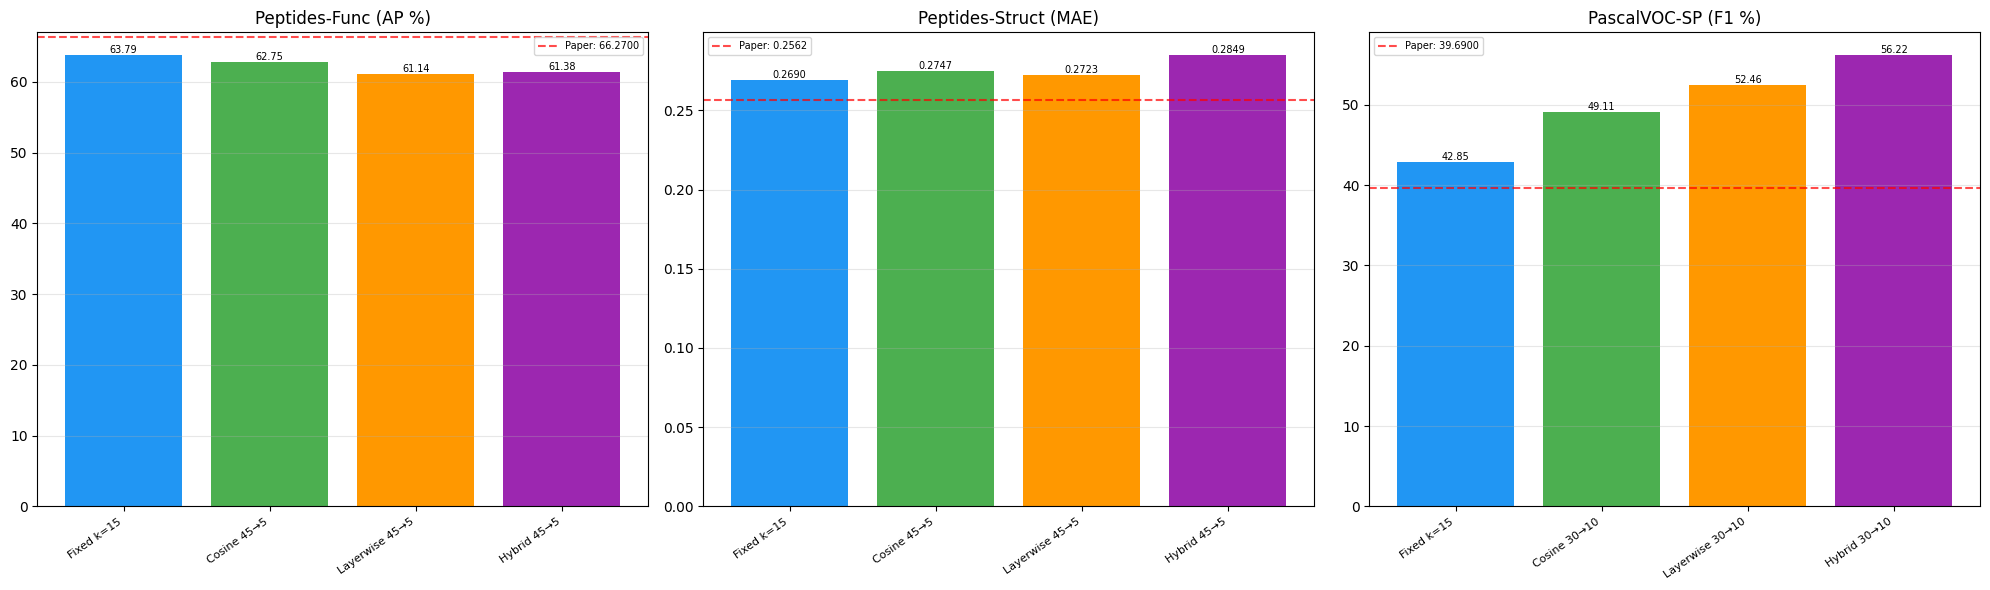

Saved to /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/method_comparison_bars.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (dataset_key, rdict) in enumerate([
    ('peptides_func', annealing_results_func),
    ('peptides_struct', annealing_results_struct),
    ('pascal_voc_sp', annealing_results_pascal),
]):
    ax = axes[idx]
    spec = plot_specs[dataset_key]
    names = ordered_methods(dataset_key, rdict)
    vals = [rdict[n]['test_metric'] for n in names]
    colors = [method_colors.get(n, 'gray') for n in names]

    bars = ax.bar(range(len(names)), vals, color=colors)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([display_name(n) for n in names], rotation=35, ha='right', fontsize=8)
    ax.set_title(spec['title'])
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=spec['ref'], color='red', linestyle='--', alpha=0.7,
               label=f"Paper: {spec['ref']:.4f}")
    ax.legend(fontsize=7)

    if spec['ylim'] is not None:
        ax.set_ylim(*spec['ylim'])

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height(),
            spec['bar_fmt'].format(val),
            ha='center',
            va='bottom',
            fontsize=7
        )

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'method_comparison_bars.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")

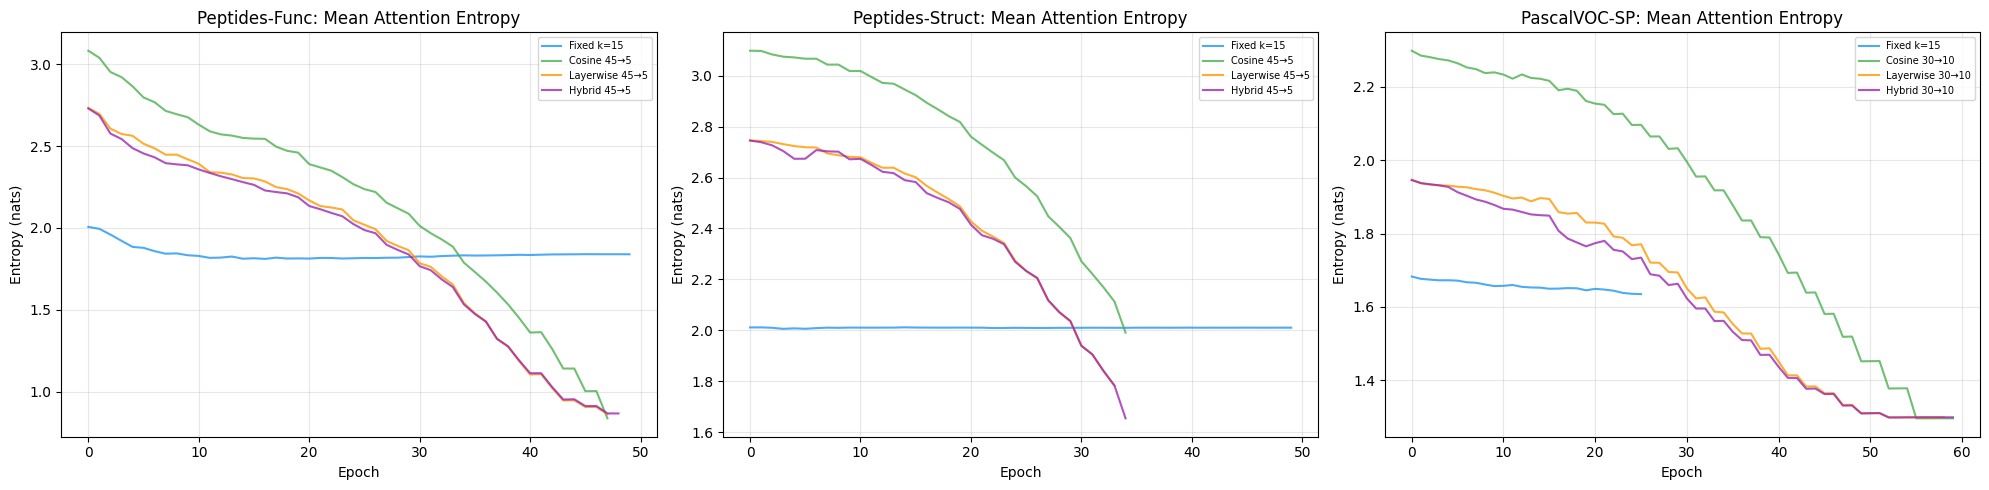

Saved to /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/attention_entropy_evolution.png

Decreasing entropy usually indicates that attention is becoming sharper or more confident.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (dataset_key, dname, rdict) in enumerate([
    ('peptides_func', 'Peptides-Func', annealing_results_func),
    ('peptides_struct', 'Peptides-Struct', annealing_results_struct),
    ('pascal_voc_sp', 'PascalVOC-SP', annealing_results_pascal),
]):
    ax = axes[idx]
    for name in ordered_methods(dataset_key, rdict):
        res = rdict[name]
        ents = res['history']['layer_entropies']
        if ents and len(ents[0]) > 0:
            mean_ent = [np.mean(e) if len(e) > 0 else 0 for e in ents]
            ax.plot(
                range(len(mean_ent)),
                mean_ent,
                label=display_name(name),
                color=method_colors.get(name, 'gray'),
                alpha=0.8
            )
    ax.set_title(f'{dname}: Mean Attention Entropy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Entropy (nats)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'attention_entropy_evolution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")
print("\nDecreasing entropy usually indicates that attention is becoming sharper or more confident.")

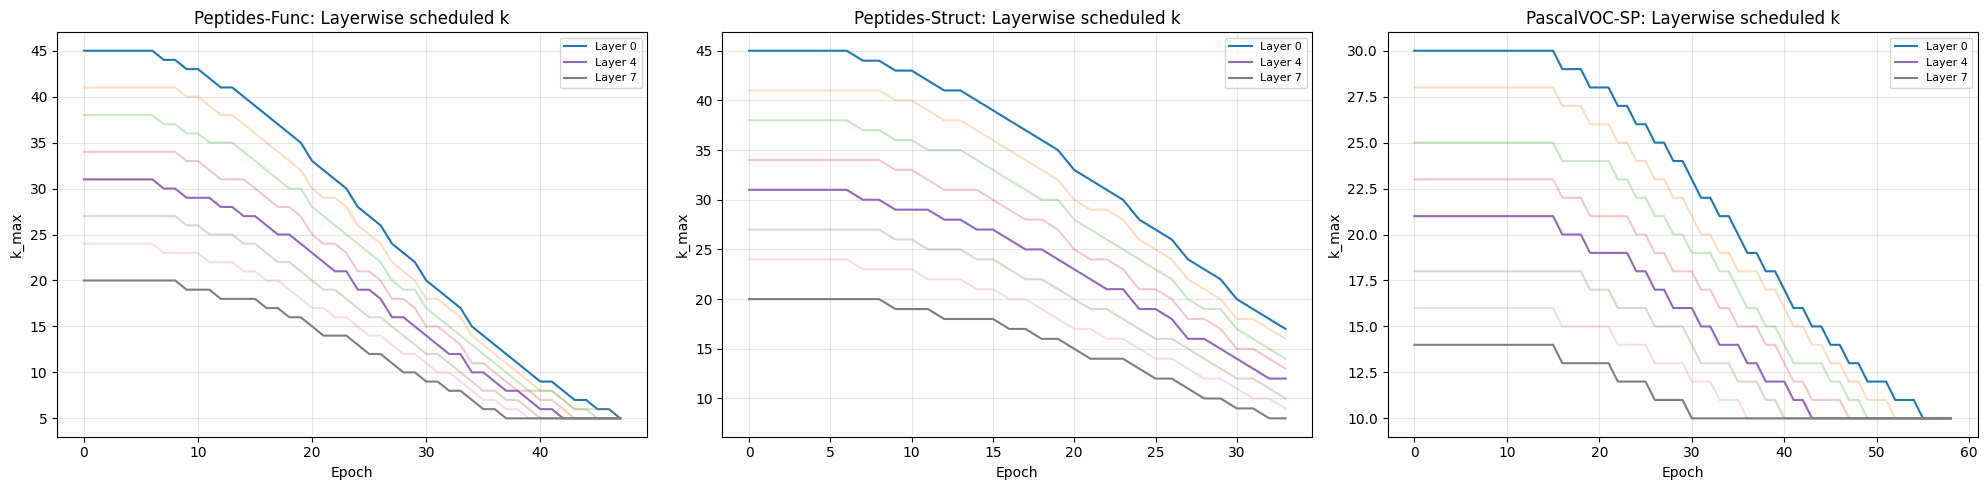

Saved to /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/per_layer_k_profiles.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (dataset_key, dname, rdict) in enumerate([
    ('peptides_func', 'Peptides-Func', annealing_results_func),
    ('peptides_struct', 'Peptides-Struct', annealing_results_struct),
    ('pascal_voc_sp', 'PascalVOC-SP', annealing_results_pascal),
]):
    ax = axes[idx]

    layerwise_method = (
        'layerwise_cosine_30to10'
        if dataset_key == 'pascal_voc_sp'
        else 'layerwise_cosine_45to5'
    )

    if layerwise_method in rdict:
        pl = rdict[layerwise_method]['history'].get('effective_k_per_layer', [])
        if pl:
            nL = len(pl[0])
            for l in range(nL):
                vals = [ep[l] for ep in pl if len(ep) > l]
                label = f'Layer {l}' if l in [0, nL // 2, nL - 1] else None
                ax.plot(
                    range(len(vals)),
                    vals,
                    alpha=1.0 if label else 0.25,
                    label=label
                )

    ax.set_title(f'{dname}: Layerwise scheduled k')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('k_max')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'per_layer_k_profiles.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")

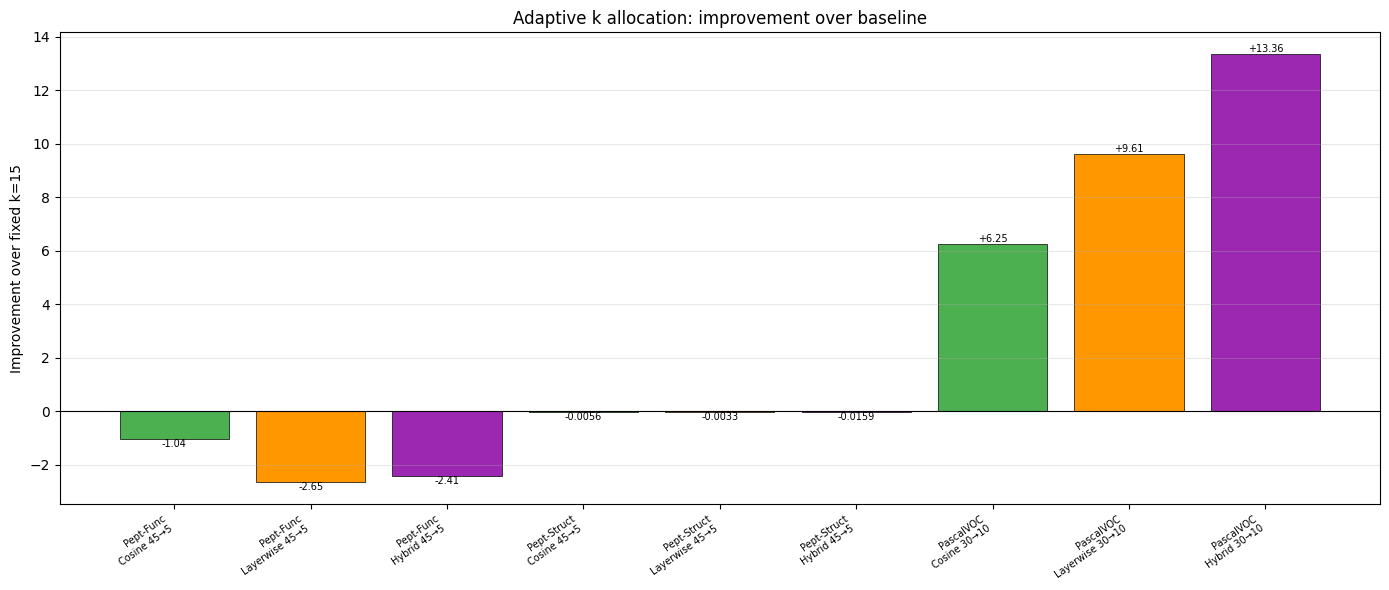

Saved to /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/improvement_over_baseline.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
labels, deltas, colors_d = [], [], []

for dataset_key, dname, rdict in [
    ('peptides_func', 'Pept-Func', annealing_results_func),
    ('peptides_struct', 'Pept-Struct', annealing_results_struct),
    ('pascal_voc_sp', 'PascalVOC', annealing_results_pascal),
]:
    higher_better = plot_specs[dataset_key]['higher_better']

    if 'fixed_k15' not in rdict:
        continue

    base = rdict['fixed_k15']['test_metric']

    for name in ordered_methods(dataset_key, rdict):
        if name == 'fixed_k15':
            continue
        delta = rdict[name]['test_metric'] - base
        if not higher_better:
            delta = -delta

        labels.append(f"{dname}\n{display_name(name)}")
        deltas.append(delta)
        colors_d.append(method_colors.get(name, 'gray'))

bars = ax.bar(range(len(deltas)), deltas, color=colors_d, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(deltas)))
ax.set_xticklabels(labels, fontsize=7, rotation=35, ha='right')
ax.set_ylabel('Improvement over fixed k=15')
ax.set_title('Adaptive k allocation: improvement over baseline')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, deltas):
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height(),
        f'{val:+.2f}' if abs(val) >= 1 else f'{val:+.4f}',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=7
    )

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'improvement_over_baseline.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")

In [ ]:
all_results = {}
for dname, rdict in [
    ('peptides_func', annealing_results_func),
    ('peptides_struct', annealing_results_struct),
    ('pascal_voc_sp', annealing_results_pascal)
]:
    all_results[dname] = {
        n: {
            'test': r['test_metric'],
            'val': r['best_val_metric'],
            'params': r['num_params'],
            'time': r['total_time'],
            'metric': r['metric_name'],
            'backend': r['backend'],
            'history': r['history']
        }
        for n, r in rdict.items()
    }

save_path = os.path.join(RESULTS_DIR, 'all_lrgb_results.json')
with open(save_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"All results saved to {save_path}")

print("\nFiles in Results directory:")
for fname in sorted(os.listdir(RESULTS_DIR)):
    fsize = os.path.getsize(os.path.join(RESULTS_DIR, fname)) / 1024
    print(f"  {fname} ({fsize:.1f} KB)")

All results saved to /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/all_lrgb_results.json

Files in Results directory:
  Data (4.0 KB)
  all_lrgb_results.json (567.3 KB)
  attention_entropy_evolution.png (186.3 KB)
  improvement_over_baseline.png (71.8 KB)
  k_scheduling_strategies.png (77.7 KB)
  method_comparison_bars.png (101.8 KB)
  pascal_voc_sp_three_seed_raw_runs.csv (284.5 KB)
  pascal_voc_sp_three_seed_raw_runs.pkl (169.0 KB)
  peptides_func_three_seed_raw_runs.csv (278.4 KB)
  peptides_func_three_seed_raw_runs.pkl (176.7 KB)
  peptides_struct_three_seed_raw_runs.csv (212.8 KB)
  peptides_struct_three_seed_raw_runs.pkl (130.0 KB)
  per_layer_k_profiles.png (254.8 KB)
  runtime_memory_bars.png (154.2 KB)
  runtime_memory_table.csv (1.4 KB)
  splits (4.0 KB)
  three_seed_raw_runs.csv (775.0 KB)
  three_seed_raw_runs.pkl (473.4 KB)
  three_seed_summary_table.csv (1.2 KB)


In [ ]:
print("=" * 80)
print("EXPERIMENT SUMMARY")
print("=" * 80)

for dataset_key, rdict in [
    ('peptides_func', annealing_results_func),
    ('peptides_struct', annealing_results_struct),
    ('pascal_voc_sp', annealing_results_pascal),
]:
    spec = plot_specs[dataset_key]
    dname = spec['title']
    ref = spec['ref']
    higher_better = spec['higher_better']

    print(f"\n--- {dname} --- (Paper GPS+k-MIP: {ref})")

    if higher_better:
        best = max(rdict.keys(), key=lambda n: rdict[n]['test_metric'])
    else:
        best = min(rdict.keys(), key=lambda n: rdict[n]['test_metric'])

    for name in ordered_methods(dataset_key, rdict):
        res = rdict[name]
        marker = " <<<" if name == best else ""
        print(
            f"  {display_name(name):<35} "
            f"Test: {res['test_metric']:.4f} | "
            f"Val: {res['best_val_metric']:.4f} | "
            f"{res['total_time']:.0f}s | "
            f"backend={res['backend']}{marker}"
        )

print(f"\nAll results and figures saved to: {RESULTS_DIR}")
print("Notebook complete: paper-aligned k-MIP with layerwise + querywise adaptive k.")

EXPERIMENT SUMMARY

--- Peptides-Func (AP %) --- (Paper GPS+k-MIP: 66.27)
  Fixed k=15                          Test: 63.7901 | Val: 65.0420 | 1617s | backend=dense <<<
  Cosine 45→5                         Test: 62.7498 | Val: 62.8844 | 1658s | backend=dense
  Layerwise 45→5                      Test: 61.1364 | Val: 63.9168 | 1580s | backend=dense
  Hybrid 45→5                         Test: 61.3805 | Val: 63.1722 | 1735s | backend=dense

--- Peptides-Struct (MAE) --- (Paper GPS+k-MIP: 0.2562)
  Fixed k=15                          Test: 0.2690 | Val: 0.2645 | 1634s | backend=dense <<<
  Cosine 45→5                         Test: 0.2747 | Val: 0.2661 | 1216s | backend=dense
  Layerwise 45→5                      Test: 0.2723 | Val: 0.2654 | 1158s | backend=dense
  Hybrid 45→5                         Test: 0.2849 | Val: 0.2781 | 1257s | backend=dense

--- PascalVOC-SP (F1 %) --- (Paper GPS+k-MIP: 39.69)
  Fixed k=15                          Test: 42.8541 | Val: 42.5998 | 2060s | backend=de

## 11. Extended Analysis

Additional tables and ablations built from the 3-seed sweep data.


### 11.5 Runtime and peak-memory summary

Run this **after** you have created `df_3seed_all`.


In [ ]:
# Runtime and peak-memory table
def build_runtime_memory_table(df):
    tab = (
        df.groupby(["dataset", "method"], as_index=False)
          .agg(
              wall_time_mean=("wall_time_seconds", "mean"),
              wall_time_std=("wall_time_seconds", "std"),
              train_time_mean=("train_time_seconds", "mean"),
              train_time_std=("train_time_seconds", "std"),
              peak_alloc_mean=("gpu_peak_allocated_mb", "mean"),
              peak_alloc_std=("gpu_peak_allocated_mb", "std"),
              peak_reserved_mean=("gpu_peak_reserved_mb", "mean"),
              peak_reserved_std=("gpu_peak_reserved_mb", "std"),
              params=("num_params", "mean"),
          )
    )

    tab["wall_time_mean±std"] = tab.apply(lambda r: format_mean_std(r["wall_time_mean"], r["wall_time_std"], 1) + " s", axis=1)
    tab["train_time_mean±std"] = tab.apply(lambda r: format_mean_std(r["train_time_mean"], r["train_time_std"], 1) + " s", axis=1)
    tab["peak_alloc_mean±std"] = tab.apply(lambda r: format_mean_std(r["peak_alloc_mean"], r["peak_alloc_std"], 1) + " MB", axis=1)
    tab["peak_reserved_mean±std"] = tab.apply(lambda r: format_mean_std(r["peak_reserved_mean"], r["peak_reserved_std"], 1) + " MB", axis=1)

    return tab[[
        "dataset", "method", "params",
        "wall_time_mean±std", "train_time_mean±std",
        "peak_alloc_mean±std", "peak_reserved_mean±std"
    ]]

runtime_memory_table = build_runtime_memory_table(df_3seed_all)
display(runtime_memory_table)
runtime_memory_table.to_csv(os.path.join(RESULTS_DIR, "runtime_memory_table.csv"), index=False)

print("Runtime/peak-memory helper ready.")


,dataset,method,params,wall_time_mean±std,train_time_mean±std,peak_alloc_mean±std,peak_reserved_mean±std
0,PascalVOC-SP,Cosine 30→10,314725.0,4335.4 ± 560.0 s,4238.2 ± 559.4 s,1093.9 ± 0.7 MB,1176.7 ± 1.2 MB
1,PascalVOC-SP,Fixed k=15,314725.0,3128.9 ± 1638.3 s,3032.2 ± 1638.2 s,966.1 ± 0.3 MB,1018.0 ± 0.0 MB
2,PascalVOC-SP,Hybrid 30→10,314725.0,4305.1 ± 1658.2 s,4207.6 ± 1659.0 s,1024.4 ± 0.7 MB,1170.7 ± 2.3 MB
3,PascalVOC-SP,Layerwise 30→10,314725.0,3898.1 ± 1501.9 s,3801.6 ± 1501.7 s,1024.4 ± 0.7 MB,1070.7 ± 2.3 MB
4,Peptides-Func,Cosine 45→5,313934.0,1540.8 ± 177.2 s,1536.6 ± 177.2 s,3013.0 ± 7.5 MB,3410.7 ± 10.1 MB
5,Peptides-Func,Fixed k=15,313934.0,1639.2 ± 19.8 s,1635.0 ± 19.8 s,2122.8 ± 6.6 MB,2308.7 ± 1.2 MB
6,Peptides-Func,Hybrid 45→5,313934.0,1697.5 ± 79.9 s,1693.0 ± 79.8 s,2633.6 ± 7.5 MB,3197.3 ± 3.1 MB
7,Peptides-Func,Layerwise 45→5,313934.0,1500.6 ± 77.8 s,1496.6 ± 77.7 s,2633.6 ± 7.5 MB,2801.3 ± 9.5 MB
8,Peptides-Struct,Cosine 45→5,313987.0,1053.2 ± 146.2 s,1049.1 ± 146.4 s,3013.0 ± 7.5 MB,3405.3 ± 11.5 MB
9,Peptides-Struct,Fixed k=15,313987.0,1643.3 ± 10.0 s,1639.3 ± 10.0 s,2122.8 ± 6.6 MB,2308.0 ± 0.0 MB


Runtime/peak-memory helper ready.


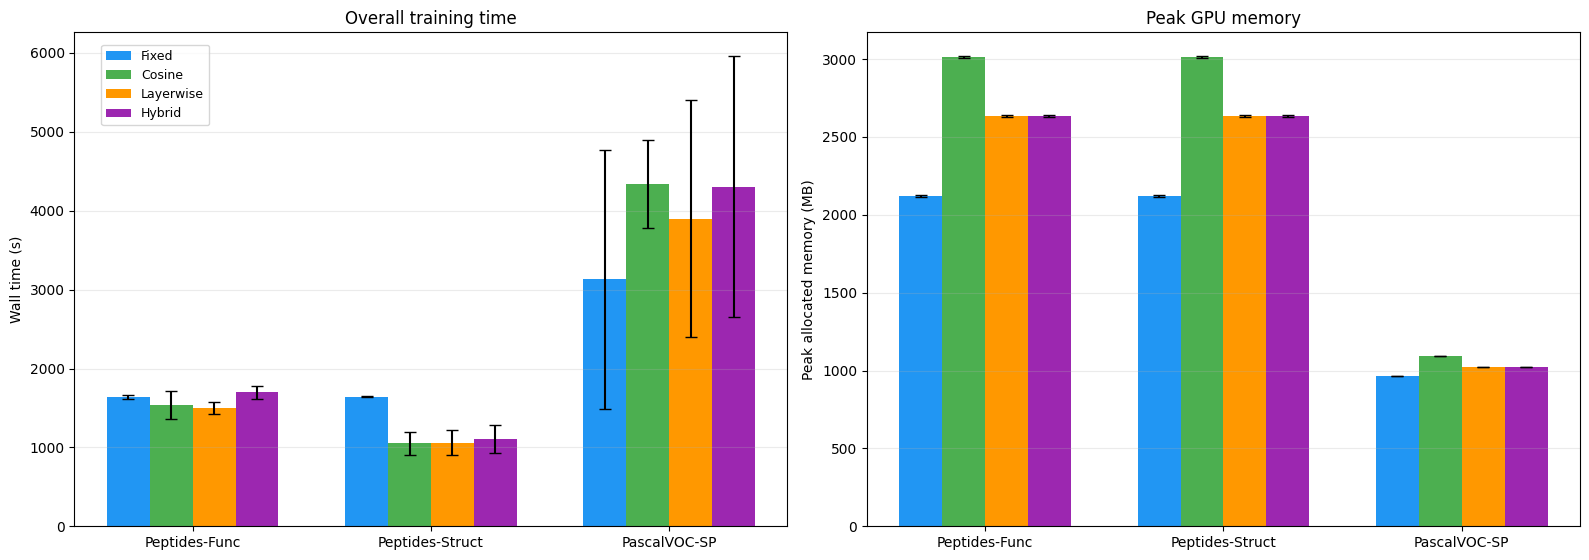

Saved: /content/drive/MyDrive/Hillary Courses/Geometric Deep Learning/Mini Project/FinalResults/runtime_memory_bars.png


In [ ]:

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---- path ----
runtime_csv = os.path.join(RESULTS_DIR, "runtime_memory_table.csv")
rt = pd.read_csv(runtime_csv)

# ---- parse "mean ± std" strings like "4335.4 ± 560.0 s" or "1093.9 ± 0.7 MB" ----
def parse_mean_std_cell(x):
    if pd.isna(x):
        return np.nan, np.nan
    s = str(x).strip()
    s = s.replace(" MB", "").replace(" s", "")
    m = re.match(r"^\s*([0-9.]+)\s*±\s*([0-9.]+)\s*$", s)
    if m:
        return float(m.group(1)), float(m.group(2))
    try:
        return float(s), np.nan
    except:
        return np.nan, np.nan

# ---- unpack columns ----
rt[["wall_time_mean", "wall_time_std"]] = rt["wall_time_mean±std"].apply(
    lambda x: pd.Series(parse_mean_std_cell(x))
)
rt[["train_time_mean", "train_time_std"]] = rt["train_time_mean±std"].apply(
    lambda x: pd.Series(parse_mean_std_cell(x))
)
rt[["peak_alloc_mean", "peak_alloc_std"]] = rt["peak_alloc_mean±std"].apply(
    lambda x: pd.Series(parse_mean_std_cell(x))
)
rt[["peak_reserved_mean", "peak_reserved_std"]] = rt["peak_reserved_mean±std"].apply(
    lambda x: pd.Series(parse_mean_std_cell(x))
)

# ---- ordering ----
dataset_order = ["Peptides-Func", "Peptides-Struct", "PascalVOC-SP"]
method_order = [
    "Fixed k=15",
    "Cosine 45→5",
    "Layerwise 45→5",
    "Hybrid 45→5",
    "Cosine 30→10",
    "Layerwise 30→10",
    "Hybrid 30→10",
]

rt["dataset"] = pd.Categorical(rt["dataset"], categories=dataset_order, ordered=True)
rt["method"] = pd.Categorical(rt["method"], categories=method_order, ordered=True)
rt = rt.sort_values(["dataset", "method"]).reset_index(drop=True)

# ---- keep only methods that exist for each dataset ----
dataset_to_methods = {
    "Peptides-Func": ["Fixed k=15", "Cosine 45→5", "Layerwise 45→5", "Hybrid 45→5"],
    "Peptides-Struct": ["Fixed k=15", "Cosine 45→5", "Layerwise 45→5", "Hybrid 45→5"],
    "PascalVOC-SP": ["Fixed k=15", "Cosine 30→10", "Layerwise 30→10", "Hybrid 30→10"],
}

# ---- colors ----
family_colors = {
    "Fixed": "#2196F3",
    "Cosine": "#4CAF50",
    "Layerwise": "#FF9800",
    "Hybrid": "#9C27B0",
}

# map dataset-specific method names -> generic families
method_family = {
    "Fixed k=15": "Fixed",
    "Cosine 45→5": "Cosine",
    "Layerwise 45→5": "Layerwise",
    "Hybrid 45→5": "Hybrid",
    "Cosine 30→10": "Cosine",
    "Layerwise 30→10": "Layerwise",
    "Hybrid 30→10": "Hybrid",
}

family_order = ["Fixed", "Cosine", "Layerwise", "Hybrid"]


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bar_width = 0.18
x_base = np.arange(len(dataset_order))
offsets = np.linspace(-1.5 * bar_width, 1.5 * bar_width, len(family_order))

ax = axes[0]
for i, dataset in enumerate(dataset_order):
    sub = rt[rt["dataset"] == dataset].copy()
    methods = dataset_to_methods[dataset]

    fam_to_row = {}
    for method in methods:
        fam = method_family[method]
        row = sub[sub["method"] == method]
        if len(row):
            fam_to_row[fam] = row.iloc[0]

    for off, fam in zip(offsets, family_order):
        if fam not in fam_to_row:
            continue
        row = fam_to_row[fam]
        ax.bar(
            i + off,
            row["wall_time_mean"],
            width=bar_width,
            yerr=row["wall_time_std"],
            color=family_colors[fam],
            capsize=4,
        )

ax.set_xticks(x_base)
ax.set_xticklabels(dataset_order)
ax.set_ylabel("Wall time (s)")
ax.set_title("Overall training time")
ax.grid(axis="y", alpha=0.25)

ax = axes[1]
for i, dataset in enumerate(dataset_order):
    sub = rt[rt["dataset"] == dataset].copy()
    methods = dataset_to_methods[dataset]

    fam_to_row = {}
    for method in methods:
        fam = method_family[method]
        row = sub[sub["method"] == method]
        if len(row):
            fam_to_row[fam] = row.iloc[0]

    for off, fam in zip(offsets, family_order):
        if fam not in fam_to_row:
            continue
        row = fam_to_row[fam]
        ax.bar(
            i + off,
            row["peak_alloc_mean"],
            width=bar_width,
            yerr=row["peak_alloc_std"],
            color=family_colors[fam],
            capsize=4,
        )

ax.set_xticks(x_base)
ax.set_xticklabels(dataset_order)
ax.set_ylabel("Peak allocated memory (MB)")
ax.set_title("Peak GPU memory")
ax.grid(axis="y", alpha=0.25)

legend_handles = [
    Patch(facecolor=family_colors[fam], label=fam)
    for fam in family_order
]
fig.legend(
    handles=legend_handles,
    labels=family_order,
    loc="center",
    bbox_to_anchor=(0.1, 0.8),
    fontsize=9,
    frameon=True,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

save_path = os.path.join(RESULTS_DIR, "runtime_memory_bars.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {save_path}")